In [1]:
import time
import logging
import gc
import warnings
import os
import tempfile
import ast
import seaborn as sns
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import shap
import folium
import joblib
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy import stats, optimize
from shapely.geometry import LineString
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, OneHotEncoder, PolynomialFeatures
from folium.plugins import Draw
from folium import Map, Marker
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, OneHotEncoder, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split

import xgboost as xgb
from xgboost import XGBRegressor, DMatrix, train as xgb_train

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, Embedding, Flatten, Conv1D, MaxPooling1D, Reshape, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras.regularizers import l1, l2

from IPython.display import display, HTML, IFrame
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from PIL import Image
from textwrap import wrap

In [2]:
# Suppress specific warnings from XGBoost
warnings.filterwarnings(action='ignore', category=UserWarning, message='.*deprecated.*')
warnings.filterwarnings(action='ignore', category=UserWarning, message='.*not used.*')
warnings.filterwarnings(action='ignore', category=UserWarning, message='.*No visible GPU is found.*')


In [3]:
display(HTML("""
<style>
.jp-OutputArea-output {
    overflow-y: auto;
}
</style>
"""))


In [4]:
# Load the dataset
file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\Sample data from Vesna vLandedWells.xlsx'  
df = pd.read_excel(file_path)
# file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\Prakhar_Testnew.csv'  
# df = pd.read_csv(file_path)

In [5]:
# Read the first Excel sheet (cumulative data)
file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\Cumulative Prod for sample data.xlsx'
cumulative_df = pd.read_excel(file_path)

In [6]:
df = pd.merge(df, cumulative_df, on='UWI10', how='left')

In [7]:
df

,UWI10,UWI,WellName,PRIMARY_FORMATION,CompletionDate,Typecurve,BasinTC,HORIZONTIAL_WELL_LENGTH,EST_FORMATION_THICKNESS,PERCENT_IN_ZONE,...,Gas_Params_P65,Oil_Params_P80,Gas_Params_P80,Water_Params_P50,FORMATION_CONDENSED,FluidPerFoot_bblft,ProppantPerFoot,Cumulative oil mbo,Cumulative gas mmcf,Cumulative water mbbl
0,4231739846,42317398460000,SALE RANCH 20E #5H,WFMPB1,2015-11-06,proj96_B,Midland,10010.21,253.36,1.0,...,"['ModArps', '0', '0', '18500', '20.02', '1.800...","['ModArps', '0', '0', '27295', '67.35', '0.695...","['ModArps', '0', '0', '19140', '22.73', '1.800...",NaN,WCB,31.641459,1417.76,NaN,NaN,NaN
1,4231745088,42317450880000,AMOCO-BLANCHE 2-28 UNIT 1 #115,SPBYLC1,2023-11-27,proj205,Midland,10370.25,416.08,1.0,...,NaN,NaN,NaN,NaN,LSS,45.398693,1673.26,NaN,NaN,NaN
2,4231742586,42317425860000,HSC 320J #1306HC,SPBYMA1,2020-02-25,proj193,Midland,7939.82,248.79,1.0,...,"['ModArps', '9001', '2', '23280', '51.62', '1....","['ModArps', '9985', '2', '22416', '78.94', '0....","['ModArps', '9001', '2', '23179', '51.36', '1....",NaN,MSS,NaN,NaN,NaN,NaN,NaN
3,4231743077,42317430770000,MILTON #0827LS,SPBYLC1,2021-04-01,proj353,Midland,9980.49,359.71,1.0,...,NaN,NaN,NaN,NaN,LSS,46.553446,2839.68,NaN,NaN,NaN
4,4231742706,42317427060000,TY RANCH WEST #2451WB,SPBYLA2,2022-10-23,proj214_East,Midland,7538.20,255.94,1.0,...,NaN,NaN,NaN,NaN,JMS,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2944,4231742961,42317429610000,JACK MOHR UNIT 1 #0262DH,Dean,2022-01-21,Mercury_600,Midland,10533.23,201.26,1.0,...,"['ModArps', '27508', '8', '31881', '68.36', '1...","['ModArps', '17087', '2', '41003', '89.06', '0...","['ModArps', '27508', '8', '32769', '67.37', '1...","['ModArps', '32816', '2', '77092', '87.63', '0...",Dean,43.073393,2228.84,231.39,442.25,428.18
2945,4231742646,42317426460000,HAZELWOOD-GRAHAM 48D #4H,WFMPA1,2021-05-30,proj96_B,Midland,7285.02,197.68,1.0,...,"['ModArps', '1586', '1', '14499', '15.00', '1....","['ModArps', '584', '1', '18502', '64.80', '0.6...","['ModArps', '1586', '1', '14212', '15.37', '1....","['ModArps', '1168', '1', '47453', '75.06', '0....",WCA,36.261858,1702.05,214.26,431.53,391.17
2946,4231741991,42317419910000,ALLDALE SN #206WB,WFMPB1,2019-07-19,proj193,Midland,13319.58,255.41,1.0,...,"['ModArps', '34260', '4', '46808', '55.12', '1...","['ModArps', '42611', '1', '48788', '71.05', '0...","['ModArps', '34260', '4', '45871', '53.83', '1...",NaN,WCB,NaN,NaN,547.87,846.42,802.55
2947,4231738562,42317385620000,SCHENECKER -13- #20,NaN,2014-05-06,NaN,NaN,0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,17.682761,757.33,52.99,83.98,89.56


In [8]:
# Identify rows in df that do not have a match in cumulative_df
no_match_df = df[df['Cumulative oil mbo'].isnull() & 
                        df['Cumulative gas mmcf'].isnull() & 
                        df['Cumulative water mbbl'].isnull()]
# Print the UWI10 values that did not have a match
if no_match_df.empty:
    print("All UWI10 values in the detailed well data have corresponding matches in the cumulative data.")
else:
    print("UWI10 values in the detailed well data that did not have a corresponding match in the cumulative data:")
    print(no_match_df['UWI10'].tolist())

    # Print the rows with no matching cumulative data
    print("\nRows with no matching cumulative data:")
    print(no_match_df)

UWI10 values in the detailed well data that did not have a corresponding match in the cumulative data:
[4231739846, 4231745088, 4231742586, 4231743077, 4231742706, 4231742957, 4231744274, 4231741133, 4231744299, 4231741625, 4231742348, 4231743929, 4231741974, 4222738740, 4231743680, 4231743123, 4231740964, 4231744025, 4231742393, 4231743949, 4231742628, 4231741518, 4231740773, 4231744700, 4231744406, 4231741742, 4231739610, 4231744242, 4231739461, 4231744280, 4231739891, 4231740757, 4222741501, 4231740770, 4231742769, 4231743757, 4231741072, 4231743858, 4231740168, 4231742731, 4231739863, 4231743107, 4231742998, 4231743100, 4231741508, 4231743917, 4231740738, 4231744053, 4222740293, 4231742382, 4231741245, 4231741599]

Rows with no matching cumulative data:
         UWI10             UWI                             WellName  \
0   4231739846  42317398460000                   SALE RANCH 20E #5H   
1   4231745088  42317450880000       AMOCO-BLANCHE 2-28 UNIT 1 #115   
2   4231742586  423

In [9]:
# # Create new columns based on the specified formulas
# df['Cumulative oil mbo'] = df['CumLiquid'] / 1000
# df['Cumulative gas mmcf'] = df['CumGas'] / 1000
# df['Cumulative water mbbl'] = df['CumWater'] / 1000
# df['FluidPerFoot_bblft'] = df['FluidPerFoot'] / 42
# df['FORMATION_CONDENSED'] = df['FORMATION_CONDENSE']
# # Drop the original columns
# df.drop(columns=['CumLiquid', 'CumGas', 'CumWater', 'FluidPerFoot'], inplace=True)


In [10]:
# Converting UWI and UWI10 columns to text
#df['UWI10'] = df['UWI10'].astype(str).str.split('.').str[0]
#df['UWI'] = df['UWI'].astype(str).str.split('.').str[0]

# Finding duplicates based on UWI
duplicates = df[df.duplicated(subset='UWI10', keep=False)]

# Dropping duplicates and keeping the one with the highest value in EUR_30yr_Actual_Oil_P50_MBO
df_cleaned = df.sort_values('EUR_30yr_Actual_Oil_P50_MBO', ascending=False).drop_duplicates(subset='UWI10', keep='first')

# Counting number of duplicates dropped
num_duplicates_dropped = len(df) - len(df_cleaned)


In [11]:
df=df_cleaned
df

,UWI10,UWI,WellName,PRIMARY_FORMATION,CompletionDate,Typecurve,BasinTC,HORIZONTIAL_WELL_LENGTH,EST_FORMATION_THICKNESS,PERCENT_IN_ZONE,...,Gas_Params_P65,Oil_Params_P80,Gas_Params_P80,Water_Params_P50,FORMATION_CONDENSED,FluidPerFoot_bblft,ProppantPerFoot,Cumulative oil mbo,Cumulative gas mmcf,Cumulative water mbbl
2313,4231743741,42317437410000,SXSW W UNIT A #1WA,WFMPA1,2022-08-02,proj53,Midland,13817.91,196.61,1.00,...,NaN,NaN,NaN,NaN,WCA,41.366996,2002.79,229.97,214.99,489.65
1204,4231744812,42317448120000,ZEBCO 27-39 O #15JM,SPBYLA2,2023-09-01,Mercury_700,Midland,13179.85,228.24,0.80,...,NaN,NaN,NaN,NaN,JMS,43.043666,1728.11,304.47,443.37,498.51
1924,4231744006,42317440060000,SAND STORM UNIT 1 #0873JH,SPBYLB1,2022-12-06,Mercury_600,Midland,15804.52,134.03,0.53,...,NaN,NaN,NaN,NaN,JMS,48.876273,2220.92,323.64,609.65,1004.30
1675,4231743935,42317439350100,VANDENBERG WEST 12-24 UNIT #1WB,WFMPB1,2022-08-06,Mercury_600,Midland,15031.89,379.61,1.00,...,"['ModArps', '0', '0', '98014', '79.12', '1.069...","['ModArps', '0', '0', '89966', '75.09', '0.976...","['ModArps', '0', '0', '129071', '84.30', '1.02...","['ModArps', '78572', '2', '99703', '66.72', '1...",WCB,NaN,NaN,484.17,694.02,744.80
2316,4231743188,42317431880000,CERBERUS 11-23 UNIT 2 #181,SPBYLC1,2020-12-31,proj353,Midland,15086.17,374.19,1.00,...,"['ModArps', '19565', '9', '39499', '48.22', '1...","['ModArps', '19748', '9', '46002', '66.91', '1...","['ModArps', '19565', '9', '38154', '45.89', '1...","['ModArps', '51249', '5', '154277', '87.14', '...",LSS,43.464149,1597.66,777.84,854.39,1642.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2907,4231745085,42317450850000,DRIFTWOOD W UNIT B #1MS,ABOVE_SRP,2023-10-07,proj205,Midland,8543.20,NaN,0.00,...,NaN,NaN,NaN,NaN,ABOVE_SRP,NaN,NaN,94.51,120.42,0.00
2916,4231744003,42317440030000,SAND STORM UNIT 1 #0872JH,SPBYLB1,2023-01-07,Mercury_600,Midland,15987.46,129.32,0.87,...,NaN,NaN,NaN,NaN,JMS,47.636117,2194.21,266.62,637.14,662.83
2931,4231744690,42317446900000,TY RANCH WEST #2JM,SPBYLA2,2024-01-09,proj53,Midland,10921.16,248.12,1.00,...,NaN,NaN,NaN,NaN,JMS,43.192633,1820.42,50.14,35.89,0.00
2935,4231744145,42317441450000,ZEBCO 27-39 K #11WB,WFMPB1,2023-07-27,Mercury_700,Midland,13285.81,299.46,1.00,...,NaN,NaN,NaN,NaN,WCB,48.244446,1967.08,188.53,373.06,235.13


In [12]:
# Define the robust_parse function
def robust_parse(x):
    if isinstance(x, (float, int)) and np.isnan(x):
        return [None] * 7  # Handle NaNs by returning a list of Nones
    try:
        if isinstance(x, str):
            return ast.literal_eval(x)  # Attempt to parse string as a Python literal
        elif isinstance(x, list):
            return x  # If x is already a list, return it
        elif isinstance(x, (float, int)):
            return [x] + [None] * 6  # If x is a number, return it as the first element with None padding
        else:
            return [None] * 7  # Default case if parsing fails
    except Exception as e:
        return [None] * 7  # Return None values if parsing fails


In [13]:
# Columns to be parsed
param_columns = [
    'Oil_Params_P20', 'Gas_Params_P20', 'Oil_Params_P35', 'Gas_Params_P35', 
    'Oil_Params_P50', 'Gas_Params_P50', 'Oil_Params_P65', 'Gas_Params_P65', 
    'Oil_Params_P80', 'Gas_Params_P80', 'Water_Params_P50'
]

# Apply robust parsing to each column
for col in param_columns:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: [None] * 7 if pd.isna(x) else robust_parse(x))

# Ensure all values are lists before creating DataFrame
for col in param_columns:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: x if isinstance(x, list) else [None] * 7)

# Split each parameter into its own column
for col in param_columns:
    if col in df.columns:
        expanded_cols = [f'{col}_Method', f'{col}_BuildupRate', f'{col}_MonthsInProd', 
                         f'{col}_InitialProd', f'{col}_DiCoefficient', f'{col}_BCoefficient', 
                         f'{col}_LimDeclineRate']
        parsed_values = df[col].tolist()
        
        # Ensure all values are lists before creating DataFrame
        parsed_values = [val if isinstance(val, list) else [None] * 7 for val in parsed_values]
        
        temp_df = pd.DataFrame(parsed_values, columns=expanded_cols)
        
        # Convert numeric columns to float
        for num_col in expanded_cols:
            if num_col.endswith('_Method'):
                temp_df[num_col] = temp_df[num_col].astype(str)  # Ensuring 'Method' is of string type
            else:
                temp_df[num_col] = pd.to_numeric(temp_df[num_col], errors='coerce')  # Convert to numeric and handle errors
        
        # Concatenate the new columns to the original dataframe
        df = pd.concat([df, temp_df], axis=1)

# Drop the original parameter columns
df.drop(columns=param_columns, inplace=True)

In [14]:
# Handling NaN values differently for categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
for column in df.columns:
    if column in categorical_columns:
        df[column] = df[column].fillna('Unknown')  # Using 'Unknown' for categorical data
    else:
        df[column] = df[column].fillna(0)  # Assuming 0 is a reasonable fill for numerical data
# Drop rows where any of the new parameter columns have missing data
df.dropna(subset=[col for col in df.columns if 'Params_P50' in col], inplace=True)

In [15]:
#df.columns
dfnew= df[['UWI10','Typecurve']].drop_duplicates()
dfnew.groupby('Typecurve',as_index=False).count()

,Typecurve,UWI10
0,Mercury_600,405
1,Mercury_700,170
2,Unknown,332
3,proj101_Central,16
4,proj101_North,207
5,proj193,136
6,proj205,64
7,proj214_East,97
8,proj214_West,82
9,proj278,56


In [16]:
# Drop rows where 'FluidPerFoot_bblft' or 'ProppantPerFoot' are zero
df = df[(df['FluidPerFoot_bblft'] != 0) & (df['ProppantPerFoot'] != 0)]
df = df[(df['EUR_30yr_Actual_Gas_P50_MMCF'] != 0) & (df['EUR_30yr_Actual_Oil_P50_MBO'] != 0) & (df['EUR_30yr_Actual_Water_P50_MBBL'] != 0)]
df = df[(df['HEELPOINT_LAT'] != 0)]

In [17]:
# Define a function to replace zeros with the P50 value for the same category
def replace_zeros_with_P50(df):
    # Replace for EUR values
    phases = ['Oil', 'Gas', 'Water']  # Assuming Water is also needed; adjust as necessary
    years = ['30yr']  # Adjust or extend if there are other year ranges
    
    for phase in phases:
        for year in years:
            p50_col = f'EUR_{year}_Actual_{phase}_P50_' + ('MBO' if phase != 'Gas' else 'MMCF')
            if phase == 'Water':
                p50_col = f'EUR_{year}_Actual_{phase}_P50_MBBL'  # Assuming water is measured in MBBL

            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'EUR_{year}_Actual_{phase}_{p}_' + ('MBO' if phase != 'Gas' else 'MMCF')
                if phase == 'Water':
                    p_col = f'EUR_{year}_Actual_{phase}_{p}_MBBL'
                
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

    # Replace for parameters
    params = ['Method', 'BuildupRate', 'MonthsInProd', 'InitialProd', 'DiCoefficient', 'BCoefficient', 'LimDeclineRate']
    ###Log
    for phase in ['Oil', 'Gas', 'Water']:  # Assuming Water parameters are also needed
        for param in params:
            p50_col = f'{phase}_Params_P50_{param}'
            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'{phase}_Params_{p}_{param}'
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

In [18]:
replace_zeros_with_P50(df)

In [19]:
# Drop rows where latitude or longitude values are missing
df.dropna(subset=['HEELPOINT_LAT', 'HEELPOINT_LON', 'MIDPOINT_LAT', 'MIDPOINT_LON', 'TOEPOINT_LAT', 'TOEPOINT_LON'], inplace=True)

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['HEELPOINT_LON'], df['HEELPOINT_LAT']))

# Create a LineString for each well
gdf['line'] = gdf.apply(lambda row: LineString([
    (row['HEELPOINT_LON'], row['HEELPOINT_LAT']),
    (row['MIDPOINT_LON'], row['MIDPOINT_LAT']),
    (row['TOEPOINT_LON'], row['TOEPOINT_LAT'])
]), axis=1)

# Create a GeoDataFrame with the LineStrings
line_gdf = gpd.GeoDataFrame(gdf, geometry='line')

# Calculate bounds to set the map's initial view
bounds = line_gdf.total_bounds  # [minx, miny, maxx, maxy]
center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]  # [(miny + maxy)/2, (minx + maxx)/2]

# Create a folium map centered on the calculated center
m = folium.Map(location=center, zoom_start=10)

# Fit map to bounds
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])


# Add the lines to the map
for _, row in line_gdf.iterrows():
    line_points = [
        (row['HEELPOINT_LAT'], row['HEELPOINT_LON']),
        (row['MIDPOINT_LAT'], row['MIDPOINT_LON']),
        (row['TOEPOINT_LAT'], row['TOEPOINT_LON'])
    ]
    folium.PolyLine(line_points, color='blue').add_to(m)
    # Add marker for midpoint with a popup showing coordinates or other info
    folium.Marker(location=line_points[1], popup=f'Well ID: {row["WellName"]}', tooltip='Click for info').add_to(m)

# Add draw control to the map to allow for area selection
draw = Draw(export=True)
m.add_child(draw)

# Display the map in the Jupyter notebook
m.save('wells_map.html')
#display(IFrame('wells_map.html', width=700, height=500))


In [20]:
# def add_neighbor_eur_cumulative(df):
#     if df is None:
#         raise ValueError("The input DataFrame is None. Please provide a valid DataFrame.")

#     # Check if the UWI column exists
#     if 'UWI' not in df.columns:
#         raise ValueError("The input DataFrame does not contain the 'UWI' column.")

#     # Define the EUR columns we're interested in
#     eur_oil_columns = ['EUR_30yr_Actual_Oil_P20_MBO', 'EUR_30yr_Actual_Oil_P35_MBO', 
#                        'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Oil_P65_MBO', 
#                        'EUR_30yr_Actual_Oil_P80_MBO']
#     eur_gas_columns = ['EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Gas_P35_MMCF', 
#                        'EUR_30yr_Actual_Gas_P50_MMCF', 'EUR_30yr_Actual_Gas_P65_MMCF', 
#                        'EUR_30yr_Actual_Gas_P80_MMCF']
#     cumulative_columns = ['Cumulative oil mbo', 'Cumulative gas mmcf', 'Cumulative water mbbl']

#     # Check if the required EUR columns exist
#     missing_columns = [col for col in eur_oil_columns + eur_gas_columns + cumulative_columns if col not in df.columns]
#     if missing_columns:
#         raise ValueError(f"The input DataFrame is missing the following required columns: {missing_columns}")

#     # Create a mapping DataFrame that will be used for mapping EUR values
#     eur_cumulative_map = df.set_index('UWI')[eur_oil_columns + eur_gas_columns + cumulative_columns].fillna(0).copy()

#     # Create a dictionary to hold the new columns
#     new_columns = {}

#     # Iterate over NNAZ and NNSZ columns
#     for prefix in ['NNAZ', 'NNSZ']:
#         num_cols = 6 if prefix == 'NNAZ' else 2  # Assuming 6 NNAZ and 2 NNSZ columns
#         for i in range(1, num_cols + 1):
#             uwi_col = f'{prefix}_{i}_UWI'
#             if uwi_col in df.columns:  # Ensure the UWI column exists
#                 for eur_col in eur_oil_columns + eur_gas_columns + cumulative_columns:
#                     new_col_name = f'{prefix}_{i}_{eur_col}'
#                     # Use the map function to add EUR values from the eur_cumulative_map DataFrame
#                     new_columns[new_col_name] = df[uwi_col].map(eur_cumulative_map[eur_col])

#     # Concatenate the new columns to the original dataframe
#     df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)

#     return df

In [21]:
# def add_neighbor_eur_cumulative(df):
#     if df is None:
#         raise ValueError("The input DataFrame is None. Please provide a valid DataFrame.")

#     # Check if the UWI column exists
#     if 'UWI' not in df.columns:
#         raise ValueError("The input DataFrame does not contain the 'UWI' column.")

#     # Define the EUR columns we're interested in
#     eur_oil_columns = ['EUR_30yr_Actual_Oil_P20_MBO', 'EUR_30yr_Actual_Oil_P35_MBO', 
#                        'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Oil_P65_MBO', 
#                        'EUR_30yr_Actual_Oil_P80_MBO']
#     eur_gas_columns = ['EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Gas_P35_MMCF', 
#                        'EUR_30yr_Actual_Gas_P50_MMCF', 'EUR_30yr_Actual_Gas_P65_MMCF', 
#                        'EUR_30yr_Actual_Gas_P80_MMCF']
#     cumulative_columns = ['Cumulative oil mbo', 'Cumulative gas mmcf', 'Cumulative water mbbl']

#     # Check if the required EUR columns exist
#     missing_columns = [col for col in eur_oil_columns + eur_gas_columns + cumulative_columns if col not in df.columns]
#     if missing_columns:
#         raise ValueError(f"The input DataFrame is missing the following required columns: {missing_columns}")

#     # Create a mapping DataFrame that will be used for mapping EUR values
#     # Ensure the UWI values are unique by aggregating
#     eur_cumulative_map = df.groupby('UWI')[eur_oil_columns + eur_gas_columns + cumulative_columns].mean().fillna(0).copy()

#     # Create a dictionary to hold the new columns
#     new_columns = {}

#     # Iterate over NNAZ and NNSZ columns
#     for prefix in ['NNAZ', 'NNSZ']:
#         num_cols = 6 if prefix == 'NNAZ' else 2  # Assuming 6 NNAZ and 2 NNSZ columns
#         for i in range(1, num_cols + 1):
#             uwi_col = f'{prefix}_{i}_UWI'
#             if uwi_col in df.columns:  # Ensure the UWI column exists
#                 for eur_col in eur_oil_columns + eur_gas_columns + cumulative_columns:
#                     new_col_name = f'{prefix}_{i}_{eur_col}'
#                     # Use the map function to add EUR values from the eur_cumulative_map DataFrame
#                     new_columns[new_col_name] = df[uwi_col].map(eur_cumulative_map[eur_col])

#     # Concatenate the new columns to the original dataframe
#     df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)

#     return df


In [22]:
def add_neighbor_eur_cumulative(df):
    if df is None:
        raise ValueError("The input DataFrame is None. Please provide a valid DataFrame.")

    # Check if the UWI10 column exists
    if 'UWI10' not in df.columns:
        raise ValueError("The input DataFrame does not contain the 'UWI10' column.")

    # Define the EUR columns we're interested in
    eur_oil_columns = ['EUR_30yr_Actual_Oil_P20_MBO', 'EUR_30yr_Actual_Oil_P35_MBO', 
                       'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Oil_P65_MBO', 
                       'EUR_30yr_Actual_Oil_P80_MBO']
    eur_gas_columns = ['EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Gas_P35_MMCF', 
                       'EUR_30yr_Actual_Gas_P50_MMCF', 'EUR_30yr_Actual_Gas_P65_MMCF', 
                       'EUR_30yr_Actual_Gas_P80_MMCF']
    cumulative_columns = ['Cumulative oil mbo', 'Cumulative gas mmcf', 'Cumulative water mbbl']

    # Check if the required EUR columns exist
    missing_columns = [col for col in eur_oil_columns + eur_gas_columns + cumulative_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"The input DataFrame is missing the following required columns: {missing_columns}")

    # Create a mapping DataFrame that will be used for mapping EUR values
    # Ensure the UWI10 values are unique by aggregating
    eur_cumulative_map = df.groupby('UWI10')[eur_oil_columns + eur_gas_columns + cumulative_columns].mean().fillna(0).copy()

    # Create a dictionary to hold the new columns
    new_columns = {}

    # Iterate over NNAZ and NNSZ columns
    for prefix in ['NNAZ', 'NNSZ']:
        num_cols = 6 if prefix == 'NNAZ' else 2  # Assuming 6 NNAZ and 2 NNSZ columns
        for i in range(1, num_cols + 1):
            uwi_col = f'{prefix}_{i}_UWI'
            if uwi_col in df.columns:  # Ensure the UWI10 column exists
                for eur_col in eur_oil_columns + eur_gas_columns + cumulative_columns:
                    new_col_name = f'{prefix}_{i}_{eur_col}'
                    # Use the map function to add EUR values from the eur_cumulative_map DataFrame
                    new_columns[new_col_name] = df[uwi_col].map(eur_cumulative_map[eur_col])

    # Concatenate the new columns to the original dataframe
    df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)

    return df

In [23]:
df = add_neighbor_eur_cumulative(df)

In [24]:
df

,UWI10,UWI,WellName,PRIMARY_FORMATION,CompletionDate,Typecurve,BasinTC,HORIZONTIAL_WELL_LENGTH,EST_FORMATION_THICKNESS,PERCENT_IN_ZONE,...,NNSZ_2_EUR_30yr_Actual_Oil_P65_MBO,NNSZ_2_EUR_30yr_Actual_Oil_P80_MBO,NNSZ_2_EUR_30yr_Actual_Gas_P20_MMCF,NNSZ_2_EUR_30yr_Actual_Gas_P35_MMCF,NNSZ_2_EUR_30yr_Actual_Gas_P50_MMCF,NNSZ_2_EUR_30yr_Actual_Gas_P65_MMCF,NNSZ_2_EUR_30yr_Actual_Gas_P80_MMCF,NNSZ_2_Cumulative oil mbo,NNSZ_2_Cumulative gas mmcf,NNSZ_2_Cumulative water mbbl
2316,4231743188,42317431880000,CERBERUS 11-23 UNIT 2 #181,SPBYLC1,2020-12-31,proj353,Midland,15086.17,374.19,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,4231742121,42317421210000,VLT SAKO BAVARIAN UNIT #0053WA,WFMPA1,2020-01-08,proj101_North,Midland,10125.99,199.04,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,4231741668,42317416680100,VLT BROWNING HUNTER UNIT #0011WA,WFMPA1,2019-09-15,proj101_North,Midland,10654.78,201.81,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
688,4231743439,42317434390000,GUNSMOKE 1-40 A #1JM,SPBYLB1,2021-07-27,proj96_B,Midland,10049.90,128.14,0.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2144,4231742029,42317420290000,WOODY 6-35 UNIT 1 #133,SPBYLB1,2019-09-13,proj58,Midland,10474.79,121.65,0.71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2274,4231742711,42317427110000,PATRICIA UNIT 2 #4816AR,WFMPA1,2021-07-20,Mercury_600,Midland,10464.48,200.21,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
965,4231742330,42317423300100,NORRIS UNIT 32-H #3312AH,Wolfcamp A,2021-09-21,Mercury_600,Midland,10875.90,199.54,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
499,4231743953,42317439530000,DIRE WOLF UNIT 2 #0437SH,SPBYMA1,2022-09-13,Mercury_600,Midland,10841.16,256.97,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2220,4231743951,42317439510000,DIRE WOLF UNIT 2 #0435SH,SPBYMA1,2022-09-24,Mercury_600,Midland,10597.02,254.19,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
columns_to_drop=['UWI10', 'CompletionDate' ,'UWI', 'WellName','NNAZ_1_UWI','NNAZ_2_UWI','NNAZ_3_UWI','NNAZ_4_UWI','NNAZ_5_UWI','NNAZ_6_UWI','NNSZ_1_UWI',
 'NNSZ_2_UWI','LeaseName', 'WellNumber', 'CurrentOperatorName', 'OriginalOperatorName', 'DrillingContractorName', 'PermitDate', 'SpudDate','FORMATION_CONDENSE', 'Unique_PDP_ID','EUR_30yr_Actual_Oil_P20_MBO',
 'EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Oil_P35_MBO', 'EUR_30yr_Actual_Gas_P35_MMCF', 'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Gas_P50_MMCF',
 'EUR_30yr_Actual_Oil_P65_MBO', 'EUR_30yr_Actual_Gas_P65_MMCF', 'EUR_30yr_Actual_Oil_P80_MBO', 'EUR_30yr_Actual_Gas_P80_MMCF', 'EUR_30yr_Actual_Water_P50_MBBL','WELL_TORTUOSITY','DEPTH_TO_TOP_2Q',
 'DEPTH_TO_TOP_3Q', 'DEPTH_TO_TOP_4Q', 'AZIMUTH','DEPTH_ABOVE_ZONE_2Q',  'DEPTH_ABOVE_ZONE_3Q', 'DEPTH_ABOVE_ZONE_4Q','Cumulative oil mbo', 
 'Cumulative gas mmcf', 'Cumulative water mbbl','AVERAGE_INCLINATION','DEPTH_TO_TOP_1Q','HEELPOINT_DEPTH','TOEPOINT_DEPTH',
 'NNAZ_3_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_3_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_3_EUR_30yr_Actual_Oil_P50_MBO',
 'NNAZ_3_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_3_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_3_EUR_30yr_Actual_Gas_P20_MMCF',
 'NNAZ_3_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_3_EUR_30yr_Actual_Gas_P50_MMCF', 'NNAZ_3_EUR_30yr_Actual_Gas_P65_MMCF',
 'NNAZ_3_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_3_Cumulative oil mbo', 'NNAZ_3_Cumulative gas mmcf', 'NNAZ_3_Cumulative water mbbl',
 'NNAZ_4_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_4_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_4_EUR_30yr_Actual_Oil_P50_MBO',
 'NNAZ_4_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_4_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_4_EUR_30yr_Actual_Gas_P20_MMCF',
 'NNAZ_4_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_4_EUR_30yr_Actual_Gas_P50_MMCF', 'NNAZ_4_EUR_30yr_Actual_Gas_P65_MMCF',
 'NNAZ_4_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_4_Cumulative oil mbo', 'NNAZ_4_Cumulative gas mmcf',
 'NNAZ_4_Cumulative water mbbl', 'NNAZ_5_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_5_EUR_30yr_Actual_Oil_P35_MBO',
 'NNAZ_5_EUR_30yr_Actual_Oil_P50_MBO', 'NNAZ_5_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_5_EUR_30yr_Actual_Oil_P80_MBO',
 'NNAZ_5_EUR_30yr_Actual_Gas_P20_MMCF', 'NNAZ_5_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_5_EUR_30yr_Actual_Gas_P50_MMCF',
 'NNAZ_5_EUR_30yr_Actual_Gas_P65_MMCF', 'NNAZ_5_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_5_Cumulative oil mbo',
 'NNAZ_5_Cumulative gas mmcf', 'NNAZ_5_Cumulative water mbbl', 'NNAZ_6_EUR_30yr_Actual_Oil_P20_MBO',
 'NNAZ_6_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_6_EUR_30yr_Actual_Oil_P50_MBO', 'NNAZ_6_EUR_30yr_Actual_Oil_P65_MBO',
 'NNAZ_6_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_6_EUR_30yr_Actual_Gas_P20_MMCF', 'NNAZ_6_EUR_30yr_Actual_Gas_P35_MMCF',
 'NNAZ_6_EUR_30yr_Actual_Gas_P50_MMCF', 'NNAZ_6_EUR_30yr_Actual_Gas_P65_MMCF', 'NNAZ_6_EUR_30yr_Actual_Gas_P80_MMCF',
 'NNAZ_6_Cumulative oil mbo', 'NNAZ_6_Cumulative gas mmcf', 'NNAZ_6_Cumulative water mbbl','NNSZ_1_FORMATION', 'NNSZ_2_FORMATION','DEPTH_ABOVE_ZONE_1Q',
 'NNAZ_1_FORMATION', 'NNAZ_2_FORMATION', 
                 'NNAZ_3_FORMATION', 'NNAZ_4_FORMATION', 'NNAZ_5_FORMATION', 'NNAZ_6_FORMATION',
 'NNAZ_1_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_1_EUR_30yr_Actual_Oil_P35_MBO',  'NNAZ_1_EUR_30yr_Actual_Oil_P65_MBO',
 'NNAZ_1_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_1_EUR_30yr_Actual_Gas_P20_MMCF', 'NNAZ_1_EUR_30yr_Actual_Gas_P35_MMCF',
 'NNAZ_1_EUR_30yr_Actual_Gas_P65_MMCF', 'NNAZ_1_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_2_EUR_30yr_Actual_Oil_P20_MBO',
 'NNAZ_2_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_2_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_2_EUR_30yr_Actual_Oil_P80_MBO',
 'NNAZ_2_EUR_30yr_Actual_Gas_P20_MMCF', 'NNAZ_2_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_2_EUR_30yr_Actual_Gas_P65_MMCF',
 'NNAZ_2_EUR_30yr_Actual_Gas_P80_MMCF', 'NNSZ_1_EUR_30yr_Actual_Oil_P20_MBO', 'NNSZ_1_EUR_30yr_Actual_Oil_P35_MBO',
 'NNSZ_1_EUR_30yr_Actual_Oil_P65_MBO', 'NNSZ_1_EUR_30yr_Actual_Oil_P80_MBO', 'NNSZ_1_EUR_30yr_Actual_Gas_P20_MMCF',
 'NNSZ_1_EUR_30yr_Actual_Gas_P35_MMCF', 'NNSZ_1_EUR_30yr_Actual_Gas_P65_MMCF', 'NNSZ_1_EUR_30yr_Actual_Gas_P80_MMCF',
 'NNSZ_2_EUR_30yr_Actual_Oil_P20_MBO', 'NNSZ_2_EUR_30yr_Actual_Oil_P35_MBO', 'NNSZ_2_EUR_30yr_Actual_Oil_P65_MBO',
 'NNSZ_2_EUR_30yr_Actual_Oil_P80_MBO', 'NNSZ_2_EUR_30yr_Actual_Gas_P20_MMCF', 'NNSZ_2_EUR_30yr_Actual_Gas_P35_MMCF',
 'NNSZ_2_EUR_30yr_Actual_Gas_P65_MMCF', 'NNSZ_2_EUR_30yr_Actual_Gas_P80_MMCF','Oil_Params_P20_BuildupRate',
 'Oil_Params_P20_MonthsInProd',
 'Oil_Params_P20_InitialProd',
 'Oil_Params_P20_DiCoefficient',
 'Oil_Params_P20_BCoefficient',
 'Oil_Params_P20_LimDeclineRate',
 'Gas_Params_P20_BuildupRate',
 'Gas_Params_P20_MonthsInProd',
 'Gas_Params_P20_InitialProd',
 'Gas_Params_P20_DiCoefficient',
 'Gas_Params_P20_BCoefficient',
 'Gas_Params_P20_LimDeclineRate',
 'Oil_Params_P35_BuildupRate',
 'Oil_Params_P35_MonthsInProd',
 'Oil_Params_P35_InitialProd',
 'Oil_Params_P35_DiCoefficient',
 'Oil_Params_P35_BCoefficient',
 'Oil_Params_P35_LimDeclineRate',
 'Gas_Params_P35_BuildupRate',
 'Gas_Params_P35_MonthsInProd',
 'Gas_Params_P35_InitialProd',
 'Gas_Params_P35_DiCoefficient',
 'Gas_Params_P35_BCoefficient',
 'Gas_Params_P35_LimDeclineRate',
                 'Oil_Params_P65_BuildupRate',
 'Oil_Params_P65_MonthsInProd',
 'Oil_Params_P65_InitialProd',
 'Oil_Params_P65_DiCoefficient',
 'Oil_Params_P65_BCoefficient',
 'Oil_Params_P65_LimDeclineRate',
 'Gas_Params_P65_BuildupRate',
 'Gas_Params_P65_MonthsInProd',
 'Gas_Params_P65_InitialProd',
 'Gas_Params_P65_DiCoefficient',
 'Gas_Params_P65_BCoefficient',
 'Gas_Params_P65_LimDeclineRate',
 'Oil_Params_P80_BuildupRate',
 'Oil_Params_P80_MonthsInProd',
 'Oil_Params_P80_InitialProd',
 'Oil_Params_P80_DiCoefficient',
 'Oil_Params_P80_BCoefficient',
 'Oil_Params_P80_LimDeclineRate',
 'Gas_Params_P80_BuildupRate',
 'Gas_Params_P80_MonthsInProd',
 'Gas_Params_P80_InitialProd',
 'Gas_Params_P80_DiCoefficient',
 'Gas_Params_P80_BCoefficient',
 'Gas_Params_P80_LimDeclineRate',
                 'NNAZ_3_TRUEDIST',
 'NNAZ_3_HZDIST',
 'NNAZ_3_VTDIST',
 'NNAZ_4_TRUEDIST',
 'NNAZ_4_HZDIST',
 'NNAZ_4_VTDIST',
 'NNAZ_5_TRUEDIST',
 'NNAZ_5_HZDIST',
 'NNAZ_5_VTDIST',
 'NNAZ_6_TRUEDIST',
 'NNAZ_6_HZDIST',
 'NNAZ_6_VTDIST',
]
# Dropping the columns
df.drop(columns=columns_to_drop, inplace=True)
#months_in_prod_columns = [col for col in df.columns if '_MonthsInProd' in col]
#df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_Method' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
#months_in_prod_columns = [col for col in df.columns if 'LimDeclineRate' in col]
#df.drop(months_in_prod_columns, axis=1, inplace=True)

In [26]:
# non_null_counts = df.count()
df
# # Display columns with discrepancies in their count of non-null values
# # This assumes the DataFrame has rows where some columns may be consistently non-null
# max_count = non_null_counts.max()
# discrepancy_columns = non_null_counts[non_null_counts < max_count]
# discrepancy_columns

,PRIMARY_FORMATION,Typecurve,BasinTC,HORIZONTIAL_WELL_LENGTH,EST_FORMATION_THICKNESS,PERCENT_IN_ZONE,AVERAGE_DEPTH_BELOW_TOP,WELL_TRAJECTORY,PRIMARY_FORMATION_1Q,PRIMARY_FORMATION_2Q,...,NNSZ_1_EUR_30yr_Actual_Oil_P50_MBO,NNSZ_1_EUR_30yr_Actual_Gas_P50_MMCF,NNSZ_1_Cumulative oil mbo,NNSZ_1_Cumulative gas mmcf,NNSZ_1_Cumulative water mbbl,NNSZ_2_EUR_30yr_Actual_Oil_P50_MBO,NNSZ_2_EUR_30yr_Actual_Gas_P50_MMCF,NNSZ_2_Cumulative oil mbo,NNSZ_2_Cumulative gas mmcf,NNSZ_2_Cumulative water mbbl
2316,SPBYLC1,proj353,Midland,15086.17,374.19,1.00,-255.11,Flat,SPBYLC1,SPBYLC1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,WFMPA1,proj101_North,Midland,10125.99,199.04,1.00,-145.09,Flat,WFMPA1,WFMPA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,WFMPA1,proj101_North,Midland,10654.78,201.81,1.00,-153.11,Flat,WFMPA1,WFMPA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
688,SPBYLB1,proj96_B,Midland,10049.90,128.14,0.97,-17.65,Flat,SPBYLB1,SPBYLB1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2144,SPBYLB1,proj58,Midland,10474.79,121.65,0.71,-11.66,Flat,SPBYLA2,SPBYLB1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2274,WFMPA1,Mercury_600,Midland,10464.48,200.21,1.00,-132.29,Flat,WFMPA1,WFMPA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
965,Wolfcamp A,Mercury_600,Midland,10875.90,199.54,1.00,-131.34,Flat,WFMPA1,WFMPA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
499,SPBYMA1,Mercury_600,Midland,10841.16,256.97,1.00,-144.46,Toe Down,SPBYMA1,SPBYMA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2220,SPBYMA1,Mercury_600,Midland,10597.02,254.19,1.00,-121.86,Flat,SPBYMA1,SPBYMA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# Fill missing values with zeroumns
df = df.fillna(0)

In [28]:
non_null_counts = df.count()

# Display columns with discrepancies in their count of non-null values
# This assumes the DataFrame has rows where some columns may be consistently non-null
max_count = non_null_counts.max()
discrepancy_columns = non_null_counts[non_null_counts < max_count]
discrepancy_columns

Series([], dtype: int64)

In [29]:
# Define bounds for each basin in a dictionary.
# The keys are basin names, and the values are tuples of (lat_min, lat_max, lon_min, lon_max).
basin_bounds = {
    'Midland': {'lat_range': (29, 34), 'lon_range': (-110, -109)}
    # Add more basins with their geographic bounds 
}
def assign_basin_tc(row):
    # Check if BasinTC is 0 or missing (use pd.isna() and explicitly handle pd.NA)
    if pd.isna(row['BasinTC'])== 'Unknown' or row['BasinTC'] == 0:
        matched_basin = None
        for basin, bounds in basin_bounds.items():
            # Ensure all comparisons are done within bounds
            if ((bounds['lat_range'][0] <= row['HEELPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['HEELPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['MIDPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['MIDPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['TOEPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['TOEPOINT_LON'] <= bounds['lon_range'][1])):
                matched_basin = basin
                break
        return matched_basin if matched_basin else row['BasinTC']
    return row['BasinTC']

In [30]:
# Apply the function to each row
df['BasinTC'] = df.apply(assign_basin_tc, axis=1)
# Drop rows where 'BasinTC' is 'Unknown'
df = df[df['BasinTC'] != 'Unknown']

months_in_prod_columns = [col for col in df.columns if '_LAT' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_LON' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'COMPLETION_RELATIONSHIP' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'WELL_TRAJECTORY' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'PRIMARY_FORMATION' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'Typecurve' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)
df_orig = df

# Print the shape of the DataFrame to confirm rows have been dropped
print(f"Updated DataFrame shape: {df.shape}")

Updated DataFrame shape: (1015, 61)


In [31]:
# Ensure BasinTC and FORMATION_CONDENSED are categorical
df['BasinTC'] = df['BasinTC'].astype(str)
df['FORMATION_CONDENSED'] = df['FORMATION_CONDENSED'].astype(str)

In [32]:
# Define categorical and numerical columns excluding 'BasinTC' and 'FORMATION_CONDENSED'
categorical_columns = [col for col in df.select_dtypes(include=['object', 'category']).columns.tolist() if col not in ['BasinTC', 'FORMATION_CONDENSED']]
# Prepare data for modeling
y_headers = [col for col in df.columns if 'Params' in col]             # Define target headers dynamically if needed
numerical_columns = [col for col in df.columns if col not in categorical_columns + ['BasinTC', 'FORMATION_CONDENSED', *y_headers]]
# Update feature_columns excluding 'BasinTC' and 'FORMATION_CONDENSED'
feature_columns = numerical_columns + categorical_columns

In [33]:
list(y_headers)

['Oil_Params_P50_BuildupRate',
 'Oil_Params_P50_MonthsInProd',
 'Oil_Params_P50_InitialProd',
 'Oil_Params_P50_DiCoefficient',
 'Oil_Params_P50_BCoefficient',
 'Oil_Params_P50_LimDeclineRate',
 'Gas_Params_P50_BuildupRate',
 'Gas_Params_P50_MonthsInProd',
 'Gas_Params_P50_InitialProd',
 'Gas_Params_P50_DiCoefficient',
 'Gas_Params_P50_BCoefficient',
 'Gas_Params_P50_LimDeclineRate',
 'Water_Params_P50_BuildupRate',
 'Water_Params_P50_MonthsInProd',
 'Water_Params_P50_InitialProd',
 'Water_Params_P50_DiCoefficient',
 'Water_Params_P50_BCoefficient',
 'Water_Params_P50_LimDeclineRate']

In [34]:
list(numerical_columns)

['HORIZONTIAL_WELL_LENGTH',
 'EST_FORMATION_THICKNESS',
 'PERCENT_IN_ZONE',
 'AVERAGE_DEPTH_BELOW_TOP',
 'NNAZ_1_TRUEDIST',
 'NNAZ_1_HZDIST',
 'NNAZ_1_VTDIST',
 'NNAZ_2_TRUEDIST',
 'NNAZ_2_HZDIST',
 'NNAZ_2_VTDIST',
 'NNSZ_1_TRUEDIST',
 'NNSZ_1_HZDIST',
 'NNSZ_1_VTDIST',
 'NNSZ_2_TRUEDIST',
 'NNSZ_2_HZDIST',
 'NNSZ_2_VTDIST',
 'MIDPOINT_DEPTH',
 'AVERAGE_DEPTH_TO_NEXT_ZONE',
 'TotalDepthTVD',
 'FluidPerFoot_bblft',
 'ProppantPerFoot',
 'NNAZ_1_EUR_30yr_Actual_Oil_P50_MBO',
 'NNAZ_1_EUR_30yr_Actual_Gas_P50_MMCF',
 'NNAZ_1_Cumulative oil mbo',
 'NNAZ_1_Cumulative gas mmcf',
 'NNAZ_1_Cumulative water mbbl',
 'NNAZ_2_EUR_30yr_Actual_Oil_P50_MBO',
 'NNAZ_2_EUR_30yr_Actual_Gas_P50_MMCF',
 'NNAZ_2_Cumulative oil mbo',
 'NNAZ_2_Cumulative gas mmcf',
 'NNAZ_2_Cumulative water mbbl',
 'NNSZ_1_EUR_30yr_Actual_Oil_P50_MBO',
 'NNSZ_1_EUR_30yr_Actual_Gas_P50_MMCF',
 'NNSZ_1_Cumulative oil mbo',
 'NNSZ_1_Cumulative gas mmcf',
 'NNSZ_1_Cumulative water mbbl',
 'NNSZ_2_EUR_30yr_Actual_Oil_P50_MBO',
 'N

In [35]:
list(categorical_columns)

[]

In [36]:
# # Calculate the number of unique categories and their names for each column
# category_info = {col: {'count': df[col].nunique(), 'names': df[col].unique()} for col in categorical_columns}
# # Print the number of categories grouped by the header name
# for header, info in category_info.items():
#     print(f"{header}:")
#     print(f"  Count of Categories: {info['count']}")
#     print(f"  Categories: {info['names']}\n")
# # Print the shape of the DataFrame to confirm rows have been dropped
# print(f"Updated DataFrame shape: {df.shape}")

In [37]:
# Initialize a dictionary to keep LabelEncoders for each column
encoders = {}
# Encode categorical columns and store the encoders
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Convert and encode
    encoders[col] = le  # Store the encoder for inverse_transform

In [38]:
# Split data
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)

In [39]:
# Define function to prepare data
def remove_outliers(df, columns, threshold=3):
    for col in columns:
        df = df[(np.abs(stats.zscore(df[col])) < threshold)]
    return df
def prepare_data(df, numerical_columns, categorical_columns):
    df = df.copy()  # Create a copy of the dataframe to avoid SettingWithCopyWarning
    df.loc[:, categorical_columns] = df[categorical_columns].astype(np.int32)
    return df
# Define function to filter data by basin and formation
def filter_by_basin_and_formation(dfinput, basin, formation):
    return dfinput[(dfinput['BasinTC'] == basin) & (dfinput['FORMATION_CONDENSED'] == formation)]
def debug_shapes(train, val, test, y_headers):
    print(f'Train X shape: {train.shape}, Train Y shape: {train[y_headers].shape}')
    print(f'Val X shape: {val.shape}, Val Y shape: {val[y_headers].shape}')
    print(f'Test X shape: {test.shape}, Test Y shape: {test[y_headers].shape}')

In [40]:
# Apply scaling on train, validate and test sets
#train_df = remove_outliers(train_df, numerical_columns)
# Fit separate scalers for input features and output parameters
# input_scaler = StandardScaler()
# output_scaler = StandardScaler()

input_scaler = RobustScaler()
output_scaler = RobustScaler()

# Apply log transformation to BuildupRate and InitialProd columns before scaling
log_transform_columns = [col for col in y_headers if 'BuildupRate' in col or 'InitialProd' in col]
#log_transform_columns = [col for col in y_headers if 'MonthsInProd' in col or 'InitialProd' in col]
#log_transform_columns = [col for col in y_headers if 'InitialProd' in col]
#log_transform_columns = []

# Replace negative values with zeros before log transformation
train_df[log_transform_columns] = train_df[log_transform_columns].apply(lambda x: x.clip(lower=0))
val_df[log_transform_columns] = val_df[log_transform_columns].apply(lambda x: x.clip(lower=0))
test_df[log_transform_columns] = test_df[log_transform_columns].apply(lambda x: x.clip(lower=0))

train_df[log_transform_columns] = np.log1p(train_df[log_transform_columns])
val_df[log_transform_columns] = np.log1p(val_df[log_transform_columns])
test_df[log_transform_columns] = np.log1p(test_df[log_transform_columns])

input_scaler.fit(train_df[numerical_columns])
output_scaler.fit(train_df[y_headers])

# Prepare data by scaling numerical columns and encoding categorical columns
train_df[numerical_columns] = input_scaler.transform(train_df[numerical_columns])
train_df[y_headers] = output_scaler.transform(train_df[y_headers])
val_df[numerical_columns] = input_scaler.transform(val_df[numerical_columns])
val_df[y_headers] = output_scaler.transform(val_df[y_headers])
test_df[numerical_columns] = input_scaler.transform(test_df[numerical_columns])
test_df[y_headers] = output_scaler.transform(test_df[y_headers])

In [41]:
len(train_df)

710

In [42]:
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
unique_combinations = df[['BasinTC', 'FORMATION_CONDENSED']].drop_duplicates()

In [43]:
class RealTimePlottingCallback(Callback):
    def __init__(self, combo_description):
        super().__init__()
        self.combo_description = combo_description
        self.epochs = []
        self.losses = []
        self.val_losses = []
    def on_epoch_end(self, epoch, logs=None):
        self.epochs.append(epoch)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
    def on_train_end(self, logs=None):
        plt.figure(figsize=(10, 4))
        plt.plot(self.epochs, self.losses, label='Training Loss', color='blue')
        plt.plot(self.epochs, self.val_losses, label='Validation Loss', color='red')
        plt.title(f'Training and Validation Loss for {self.combo_description}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

In [44]:
# # Check for GPU availability and set XGBoost model configuration
# def get_xgb_regressor():
#     # try:
#     #     xgb_regressor = xgb.XGBRegressor(tree_method='gpu_hist', predictor='gpu_predictor', gpu_id=0)
#     #     xgb_regressor.fit(pd.DataFrame([[0]]), pd.DataFrame([0]))  # Attempt to fit with dummy data
#     #     return xgb_regressor
#     # except xgb.core.XGBoostError:
#         return xgb.XGBRegressor(tree_method='hist')

In [45]:
def plot_model_performance(history, title):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_ml_performance(y_true, y_pred, title):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{title} - MSE: {mse}, MAE: {mae}, R²: {r2}")

    plt.figure(figsize=(12, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.title(title)
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.show()

In [46]:
# Function to build the model
def build_model(numerical_columns, categorical_columns, df, output_size, model_type='neural_network', **kwargs):
    if model_type == 'neural_network':
        # embedding_output_dim = kwargs.get('embedding_output_dim', 10)  # Reduced embedding dimension
        # dense_layer_sizes = kwargs.get('dense_layer_sizes', [128, 32])  # Simpler dense layers
        # dropout_rate = kwargs.get('dropout_rate', 0.2)  # Reduced dropout rate
        # regularization = kwargs.get('regularization', l2(0.01))  # Added L2 regularization
        # activation = kwargs.get('activation', 'relu')
        # optimizer = kwargs.get('optimizer', 'adam')
        # loss_function = kwargs.get('loss_function', 'mse')
        embedding_output_dim = kwargs.get('embedding_output_dim', 20)
        dense_layer_sizes = kwargs.get('dense_layer_sizes', [256, 128, 64, 32])
        dropout_rate = kwargs.get('dropout_rate', 0.3)
        regularization = kwargs.get('regularization', l2(0.01))
        activation = kwargs.get('activation', 'relu')
        optimizer = kwargs.get('optimizer', 'adam')
        loss_function = kwargs.get('loss_function', 'mse')
        
        # Numerical input and reshaping for Conv1D layer
        numerical_input = Input(shape=(len(numerical_columns),), name='num_input')
        reshaped_numerical_input = Reshape((len(numerical_columns), 1))(numerical_input)
        
        # # Convolutional layers
        # x = Conv1D(filters=16, kernel_size=3, activation=activation, padding='same')(reshaped_numerical_input)  # Reduced filters
        # x = MaxPooling1D(pool_size=2)(x)
        # x = GlobalAveragePooling1D()(x)

        # Convolutional layers
        x = Conv1D(filters=32, kernel_size=3, activation=activation, padding='same')(reshaped_numerical_input)
        x = MaxPooling1D(pool_size=2)(x)
        x = Conv1D(filters=64, kernel_size=3, activation=activation, padding='same')(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Conv1D(filters=128, kernel_size=3, activation=activation, padding='same')(x)
        x = GlobalAveragePooling1D()(x)
        
        # Categorical input and embeddings
        categorical_inputs = [Input(shape=(1,), name=f'cat_input_{i}') for i, _ in enumerate(categorical_columns)]
        embeddings = [Embedding(input_dim=df[col].nunique() + 1, output_dim=embedding_output_dim, name=f'emb_{col}')(cat_input)
                      for cat_input, col in zip(categorical_inputs, categorical_columns)]
        flat_embeddings = [Flatten()(emb) for emb in embeddings]
        
        # Merging numerical and categorical inputs
        merged = Concatenate()([x] + flat_embeddings)
        
        # Dense layers
        for size in dense_layer_sizes:
            merged = Dense(size, activation=activation, kernel_regularizer=regularization)(merged)
            merged = Dropout(dropout_rate)(merged)

        output = Dense(output_size, activation='linear')(merged)  # Single output layer for all targets
        model = Model(inputs=[numerical_input] + categorical_inputs, outputs=output)

        if optimizer == 'adam':
            opt = Adam(learning_rate=0.001)
        elif optimizer == 'sgd':
            opt = SGD(learning_rate=0.001)
        elif optimizer == 'rmsprop':
            opt = RMSprop(learning_rate=0.001)

        model.compile(optimizer=opt, loss=loss_function)
        return model
    
    elif model_type in ['random_forest', 'decision_tree', 'xgboost']:
        if model_type == 'random_forest':
            model = RandomForestRegressor(n_jobs=-1, n_estimators=kwargs.get('n_estimators', 100), max_depth=kwargs.get('max_depth', 10), min_samples_split=kwargs.get('min_samples_split', 2), min_samples_leaf=kwargs.get('min_samples_leaf', 1), bootstrap=kwargs.get('bootstrap', True))
        elif model_type == 'decision_tree':
            model = DecisionTreeRegressor(max_depth=kwargs.get('max_depth', 20), min_samples_split=kwargs.get('min_samples_split', 5), min_samples_leaf=kwargs.get('min_samples_leaf', 2))
        elif model_type == 'xgboost':
            model = XGBRegressor(tree_method='hist',
                                 n_estimators=kwargs.get('n_estimators', 200),
                                 max_depth=kwargs.get('max_depth', 7),
                                 learning_rate=kwargs.get('learning_rate', 0.01),
                                 subsample=kwargs.get('subsample', 0.8),
                                 colsample_bytree=kwargs.get('colsample_bytree', 0.8),
                                 reg_alpha=kwargs.get('reg_alpha', 0.01), reg_lambda=kwargs.get('reg_lambda', 1), gamma=kwargs.get('gamma', 0.1))
        
        # Preprocessing pipeline
        numerical_transformer = Pipeline(steps=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False))
        ])

        categorical_transformer = Pipeline(steps=[
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ])

        preprocessor = ColumnTransformer(transformers=[
                ('num', numerical_transformer, numerical_columns),
                ('cat', categorical_transformer, categorical_columns)
        ])

        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
        
        return pipeline

In [47]:
# Define a helper function to format configuration dictionaries as strings
def format_config(config):
    formatted_config = ", ".join([f"{k}: {v}" for k, v in config.items() if not isinstance(v, object)])
    return f"{{{formatted_config}}}"

In [48]:
def train_and_evaluate_model(combo_train, combo_val, combo_test, numerical_columns, categorical_columns, y_headers, output_size, config, model_type, df, task_times):
    start_time = time.time()
    config_str = format_config(config)
    print(f"Starting {model_type} training with config: {config_str}")
    
    combo_train = prepare_data(combo_train, numerical_columns, categorical_columns)
    combo_val = prepare_data(combo_val, numerical_columns, categorical_columns)
    combo_test = prepare_data(combo_test, numerical_columns, categorical_columns)

    if model_type == 'neural_network':
        model = build_model(numerical_columns, categorical_columns, df, output_size, model_type=model_type, **config)
        #model = build_cnn_model(numerical_columns, categorical_columns, df, output_size, **config)
        
        real_time_plotter = RealTimePlottingCallback(combo_description=f'{config_str} - {model_type}')
        history = model.fit(
            x=[combo_train[numerical_columns].values] + [combo_train[col].astype(int).values.reshape(-1, 1) for col in categorical_columns], 
            y=combo_train[y_headers].values,  # Use entire y_headers as output
            validation_data=(
                [combo_val[numerical_columns].values] + [combo_val[col].astype(int).values.reshape(-1, 1) for col in categorical_columns],
                combo_val[y_headers].values  # Use entire y_headers as output
            ),
            epochs=500,  # Reduced number of epochs
            batch_size=50,  # Adjusted batch size
            callbacks=[
                real_time_plotter, 
                EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True), 
                ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
            ],
            verbose=0
        )      
    else:
        model = build_model(numerical_columns, categorical_columns, df, output_size, model_type=model_type, **config)
        
        if model_type == 'xgboost':
            try:
                # Extract the XGBoost estimator from the pipeline
                preprocessor = model.named_steps['preprocessor']
                xgb_model = model.named_steps['model']
                # Fit the preprocessor first
                preprocessor.fit(combo_train[numerical_columns + categorical_columns])
                combo_train_transformed = preprocessor.transform(combo_train[numerical_columns + categorical_columns])
                combo_val_transformed = preprocessor.transform(combo_val[numerical_columns + categorical_columns])
                # Fit the XGBoost model with early stopping
                xgb_model.fit(combo_train_transformed, combo_train[y_headers].values,
                              eval_set=[(combo_val_transformed, combo_val[y_headers].values)],
                              early_stopping_rounds=10, verbose=False)
            except Exception as e:
                print(f"Error during XGBoost training: {e}")
        else:
            model.fit(combo_train[numerical_columns + categorical_columns], combo_train[y_headers].values)
        
        try:
            predictions = model.predict(combo_val[numerical_columns + categorical_columns])
            plot_ml_performance(combo_val[y_headers].values, predictions, f'{model_type.upper()} - {config}')
        except NotFittedError as e:
            print(f"Model not fitted error: {e}")
    
    end_time = time.time()
    duration = end_time - start_time
    task_key = f"{model_type} - {config_str}"
    task_times[task_key] = duration
    print(f"Training completed for {task_key} in {duration:.2f} seconds")
    
    return model

In [49]:
def parallel_training(combo, combo_train, combo_val, combo_test, numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode='parallel'):
    models = {}
    basin = combo['BasinTC']
    formation = combo['FORMATION_CONDENSED']
    combo_description = f'BasinTC: {basin}, FORMATION_CONDENSED: {formation}'

    for config in tqdm(configurations, desc=f'Training Neural Networks for {combo_description}'):
        print(f"Starting training for combination: {combo_description} with config: {config}")
        model = train_and_evaluate_model(combo_train, combo_val, combo_test, numerical_columns, categorical_columns, y_headers, output_size, config, 'neural_network', df, task_times)
        models[(basin, formation, str(config))] = model
        print(f"Training completed for combination: {combo_description} with config: {config}")

    for ml_config in tqdm(ml_configurations, desc=f'Training ML models for {combo_description}'):
        print(f"Starting training for combination: {combo_description} with ML config: {ml_config}")
        model = train_and_evaluate_model(combo_train, combo_val, combo_test, numerical_columns, categorical_columns, y_headers, output_size, {}, ml_config['model_type'], df, task_times)
        models[(basin, formation, ml_config['model_type'])] = model
        print(f"Training completed for combination: {combo_description} with ML config: {ml_config}")
    
    return models

def execute_training(specific_combinations, train_df, val_df, test_df, numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode='parallel'):
    all_models = {}
    if mode == 'parallel':
        with joblib.parallel_backend('loky'):
            parallel_models = Parallel(n_jobs=-1)(
                delayed(parallel_training)(
                    combo[1],  # Access the Series part of the tuple
                    filter_by_basin_and_formation(train_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                    filter_by_basin_and_formation(val_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                    filter_by_basin_and_formation(test_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                    numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode
                ) for combo in tqdm(specific_combinations.iterrows(), total=specific_combinations.shape[0])
            )
        for model_dict in parallel_models:
            all_models.update(model_dict)
    else:
        for combo in tqdm(specific_combinations.iterrows(), total=specific_combinations.shape[0]):
            model_dict = parallel_training(
                combo[1],  # Access the Series part of the tuple
                filter_by_basin_and_formation(train_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                filter_by_basin_and_formation(val_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                filter_by_basin_and_formation(test_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode
            )
            all_models.update(model_dict)
    return all_models

In [50]:
def compute_shap_values_nn(model, numerical_data, categorical_data):
    try:
        combined_data = [numerical_data] + categorical_data
        explainer = shap.DeepExplainer(model, combined_data)
        shap_values = explainer.shap_values(combined_data)
    except Exception as e:
        logging.error(f"Error using DeepExplainer: {e}. Falling back to KernelExplainer.")
        combined_data_array = np.concatenate([numerical_data] + categorical_data, axis=1)
        explainer = shap.KernelExplainer(lambda x: model.predict([x[:, :numerical_data.shape[1]]] + 
                                                                  [x[:, i].reshape(-1, 1) for i in range(numerical_data.shape[1], combined_data_array.shape[1])]), 
                                         combined_data_array)
        shap_values = explainer.shap_values(combined_data_array, nsamples=100)
    return shap_values

# Function to compute SHAP values for ML models
def compute_shap_values_ml(model, numerical_data, categorical_data):
    combined_data = np.concatenate([numerical_data] + categorical_data, axis=1)
    try:
        if hasattr(model, 'named_steps'):
            model = model.named_steps['model']
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(combined_data)
    except Exception as e:
        logging.error(f"Error using TreeExplainer: {e}. Falling back to KernelExplainer.")
        explainer = shap.KernelExplainer(model.predict, combined_data)
        shap_values = explainer.shap_values(combined_data, nsamples=100)
    return shap_values

# Function to compute SHAP values for XGBoost
def compute_shap_values_xgb(model, numerical_data, categorical_data):
    try:
        combined_data = np.concatenate([numerical_data] + categorical_data, axis=1)
        preprocessor = model.named_steps['preprocessor']
        xgb_model = model.named_steps['model']
        
        logging.info("Transforming data using the preprocessor.")
        combined_data_transformed = preprocessor.transform(pd.DataFrame(combined_data))
        
        logging.info("Creating TreeExplainer.")
        explainer = shap.TreeExplainer(xgb_model)
        
        logging.info("Computing SHAP values.")
        shap_values = explainer.shap_values(combined_data_transformed)
    except Exception as e:
        logging.error(f"Error using TreeExplainer: {e}. Falling back to KernelExplainer.")
        try:
            explainer = shap.KernelExplainer(xgb_model.predict, combined_data_transformed)
            shap_values = explainer.shap_values(combined_data_transformed, nsamples=100)
        except Exception as e2:
            logging.error(f"Error using KernelExplainer: {e2}")
            shap_values = None
    return shap_values

def compute_shap_values(model, numerical_data, categorical_data, model_type):
    if model_type == 'neural_network':
        return compute_shap_values_nn(model, numerical_data, categorical_data)
    # if model_type == 'xgboost':
    # elif model_type == 'xgboost':
    #     return compute_shap_values_xgb(model, numerical_data, categorical_data)
    # else:
    #     return compute_shap_values_ml(model, numerical_data, categorical_data)
    # return none

def compute_and_log_shap_values(models, test_df, numerical_columns, categorical_columns, shap_sample_size=100):
    shap_values_dict = {}
    for (basin, formation, config_str), model in models.items():
        logging.info(f"Processing SHAP values for {basin} - {formation} - {config_str}")
        try:
            combo_test = filter_by_basin_and_formation(test_df, basin, formation)
            logging.info(f"Filtered test data for {basin} - {formation}")
            actual_sample_size = min(len(combo_test), shap_sample_size)
            combo_test_subset = combo_test.sample(n=actual_sample_size, random_state=42)
            numerical_data = combo_test_subset[numerical_columns].values
            categorical_data = [combo_test_subset[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
            if 'embedding_output_dim' in config_str:
                model_type = 'neural_network'
            # else:
            #     model_type = 'xgboost' if 'xgboost' in config_str.lower() else 'ml_model'
            # #model_type = 'xgboost' if 'xgboost' in config_str.lower() else 'ml_model'
                logging.info(f"Computing SHAP values using {model_type}")
                shap_values = compute_shap_values(model, numerical_data, categorical_data, model_type)
                if shap_values is not None:
                    shap_values_dict[(basin, formation, config_str)] = shap_values
                    logging.info(f"Successfully computed SHAP values for {basin} - {formation} - {config_str}")
                else:
                    logging.error(f"Failed to compute SHAP values for {basin} - {formation} - {config_str}")
            del combo_test, combo_test_subset, numerical_data, categorical_data, shap_values
            gc.collect()
        except Exception as e:
            logging.error(f"Error computing SHAP values for {basin} - {formation} - {config_str}: {e}")
    return shap_values_dict

# Function to compute and log SHAP values
# def compute_and_log_shap_values(models, test_df, numerical_columns, categorical_columns, shap_sample_size=100):
#     shap_values_dict = {}
#     for (basin, formation, config_str), model in models.items():
#         logging.info(f"Processing SHAP values for {basin} - {formation} - {config_str}")
#         try:
#             combo_test = filter_by_basin_and_formation(test_df, basin, formation)
#             logging.info(f"Filtered test data for {basin} - {formation}")
#             actual_sample_size = min(len(combo_test), shap_sample_size)
#             combo_test_subset = combo_test.sample(n=actual_sample_size, random_state=42)
#             numerical_data = combo_test_subset[numerical_columns].values
#             categorical_data = [combo_test_subset[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
#             if 'embedding_output_dim' in config_str:
#                 model_type = 'neural_network'
#             else:
#                 model_type = 'xgboost' if 'xgboost' in config_str.lower() else 'ml_model'
#             logging.info(f"Computing SHAP values using {model_type}")
#             shap_values = compute_shap_values(model, numerical_data, categorical_data, model_type)
#             if shap_values is not None:
#                 shap_values_dict[(basin, formation, config_str)] = shap_values
#                 logging.info(f"Successfully computed SHAP values for {basin} - {formation} - {config_str}")
#             else:
#                 logging.error(f"Failed to compute SHAP values for {basin} - {formation} - {config_str}")
#             del combo_test, combo_test_subset, numerical_data, categorical_data, shap_values
#             gc.collect()
#         except Exception as e:
#             logging.error(f"Error computing SHAP values for {basin} - {formation} - {config_str}: {e}")
#     return shap_values_dict

In [51]:
# def plot_shap_values(shap_values_dict, y_headers, feature_names, output_pdf):
#     # Extract the SHAP values from the dictionary
#     (basin, formation, config_str), shap_values = list(shap_values_dict.items())[0]

#     # Convert configuration to a more readable string
#     config_readable = "Neural Network"

#     # Create a temporary directory to save individual SHAP plots
#     with tempfile.TemporaryDirectory() as temp_dir:
#         plot_paths = []

#         # Generate individual SHAP summary plots
#         for i in range(shap_values.shape[2]):
#             fig, ax = plt.subplots(figsize=(8, 12))  # Increase figure size
#             shap.summary_plot(shap_values[:, :, i], feature_names=feature_names, show=False, plot_type='bar', max_display=len(feature_names))
#             plt.title(y_headers[i], fontsize=10, fontname='Arial')
#             ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1e}'))
#             plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=9, fontname='Arial')
#             plt.xticks(fontsize=10, fontname='Arial')
#             plot_path = os.path.join(temp_dir, f"shap_plot_{i}.png")
#             plt.savefig(plot_path, bbox_inches='tight', dpi=300)  # Save with higher DPI for better quality
#             plt.close(fig)
#             plot_paths.append(plot_path)

#         # Combine individual plots into a single PDF
#         with PdfPages(output_pdf) as pdf:
#             fig, axes = plt.subplots(nrows=1, ncols=len(plot_paths), figsize=(len(plot_paths) * 8, 12), sharey=True)
#             for i, plot_path in enumerate(plot_paths):
#                 img = plt.imread(plot_path)
#                 axes[i].imshow(img)
#                 axes[i].axis('off')
#                 axes[i].set_title(y_headers[i], fontsize=10, fontname='Arial')
#             fig.suptitle(config_readable, fontsize=16, fontname='Arial')
#             plt.subplots_adjust(wspace=0.09)  # Increase spacing between plots
#             pdf.savefig(fig, dpi=300)  # Save the final PDF with higher DPI
#             plt.close(fig)
# # Function to plot SHAP values and save to PDF
# # def plot_shap_values(shap_values_dict, y_headers, feature_names, output_pdf):
# #     # Create a temporary directory to save individual SHAP plots
# #     with tempfile.TemporaryDirectory() as temp_dir:
# #         plot_paths_dict = {key: [] for key in y_headers}

# #         # Generate individual SHAP summary plots
# #         for (basin, formation, config_str), shap_values in shap_values_dict.items():
# #             config_readable = config_str  # Use config_str for readability
# #             for i in range(shap_values.shape[2]):
# #                 fig, ax = plt.subplots(figsize=(8, 12))  # Increase figure size
# #                 shap.summary_plot(shap_values[:, :, i], feature_names=feature_names, show=False, plot_type='bar', max_display=len(feature_names))
# #                 plt.title(f"{config_readable} - {y_headers[i]}", fontsize=10, fontname='Arial')
# #                 ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1e}'))
# #                 plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=9, fontname='Arial')
# #                 plt.xticks(fontsize=10, fontname='Arial')
# #                 plot_path = os.path.join(temp_dir, f"shap_plot_{config_str}_{i}.png")
# #                 plt.savefig(plot_path, bbox_inches='tight', dpi=300)  # Save with higher DPI for better quality
# #                 plt.close(fig)
# #                 plot_paths_dict[y_headers[i]].append(plot_path)

# #         # Combine individual plots into a single PDF
# #         with PdfPages(output_pdf) as pdf:
# #             for y_header in y_headers:
# #                 fig, axes = plt.subplots(nrows=len(plot_paths_dict[y_header]), ncols=1, figsize=(8, len(plot_paths_dict[y_header]) * 12), sharey=True)
# #                 for j, plot_path in enumerate(plot_paths_dict[y_header]):
# #                     img = plt.imread(plot_path)
# #                     axes[j].imshow(img)
# #                     axes[j].axis('off')
# #                 fig.suptitle(f"SHAP for {y_header}", fontsize=16, fontname='Arial')
# #                 plt.subplots_adjust(hspace=0.3)  # Adjust spacing between plots
# #                 pdf.savefig(fig, dpi=300)  # Save the final PDF with higher DPI
# #                 plt.close(fig)

In [52]:
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [53]:
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
# unique_combinations = df[['BasinTC', 'FORMATION_CONDENSED']].drop_duplicates()
# Unique combinations and configurations
configurations = [
    {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': l2(0.01), 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}
]
# ml_configurations = [
# ]
ml_configurations = [
    {'model_type': 'random_forest'},
    {'model_type': 'decision_tree'},
    {'model_type': 'xgboost'}
]
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
specific_combinations = df[
    (df['BasinTC'] == 'Midland') & 
    (df['FORMATION_CONDENSED'].isin(['LSS', 'WCA', 'WCB', 'JMS']))
    #(df['FORMATION_CONDENSED'].isin(['WCA']))
].drop_duplicates(subset=['BasinTC', 'FORMATION_CONDENSED'])
output_size = len(train_df[y_headers].columns)  # Ensure output_size is defined



  0%|          | 0/4 [00:00<?, ?it/s]
Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: LSS:   0%|          | 0/1 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: LSS with config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}
Starting neural_network training with config: {}


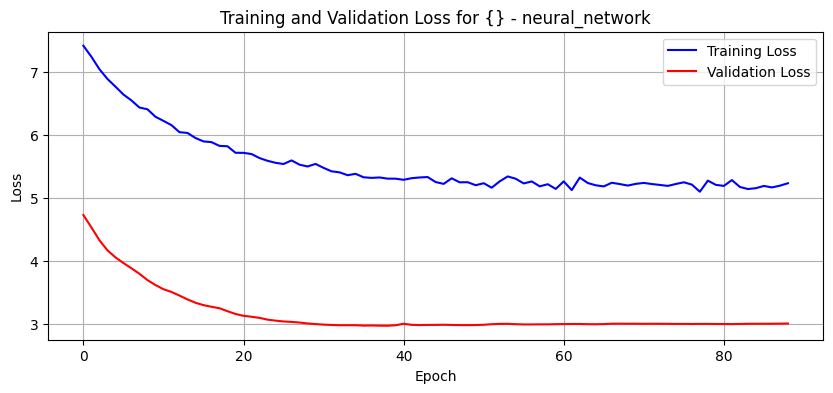


Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: LSS: 100%|██████████| 1/1 [00:08<00:00,  8.98s/it]


Training completed for neural_network - {} in 8.97 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: LSS with config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}



Training ML models for BasinTC: Midland, FORMATION_CONDENSED: LSS:   0%|          | 0/3 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: LSS with ML config: {'model_type': 'random_forest'}
Starting random_forest training with config: {}
RANDOM_FOREST - {} - MSE: 3.7102427941484017, MAE: 1.048825904238703, R²: -0.2070376646708981


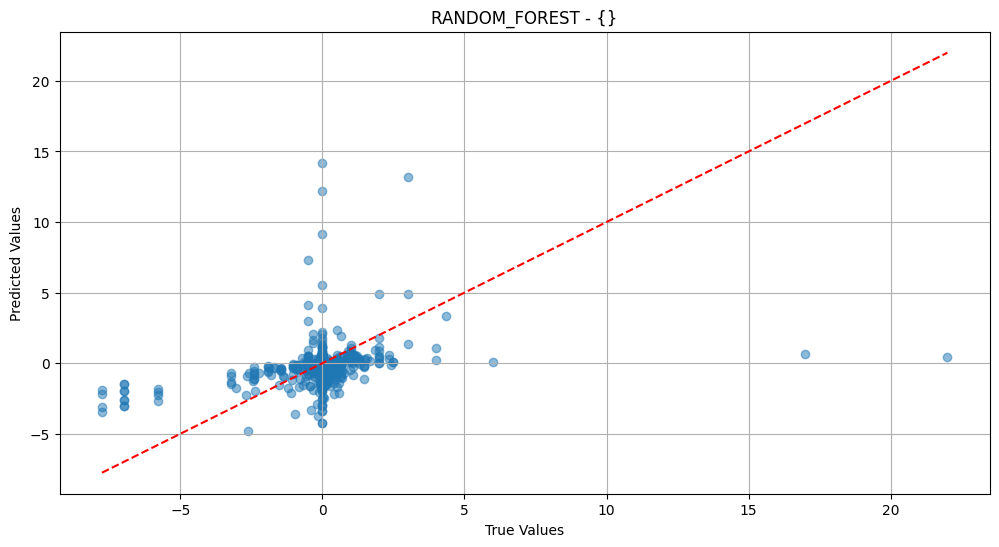


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: LSS:  33%|███▎      | 1/3 [00:00<00:01,  1.74it/s]

Training completed for random_forest - {} in 0.58 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: LSS with ML config: {'model_type': 'random_forest'}
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: LSS with ML config: {'model_type': 'decision_tree'}
Starting decision_tree training with config: {}
DECISION_TREE - {} - MSE: 7.321443403657067, MAE: 1.2404738726259796, R²: -1.6924330272374313


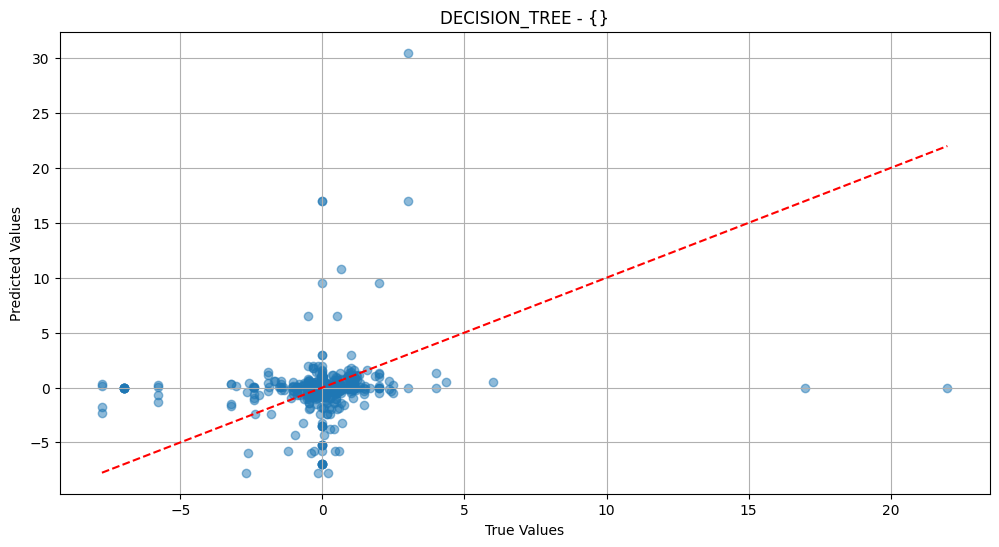


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: LSS:  67%|██████▋   | 2/3 [00:00<00:00,  2.65it/s]

Training completed for decision_tree - {} in 0.24 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: LSS with ML config: {'model_type': 'decision_tree'}
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: LSS with ML config: {'model_type': 'xgboost'}
Starting xgboost training with config: {}
XGBOOST - {} - MSE: 2.9778969286347863, MAE: 0.8248893379469787, R²: -0.26906115129678115


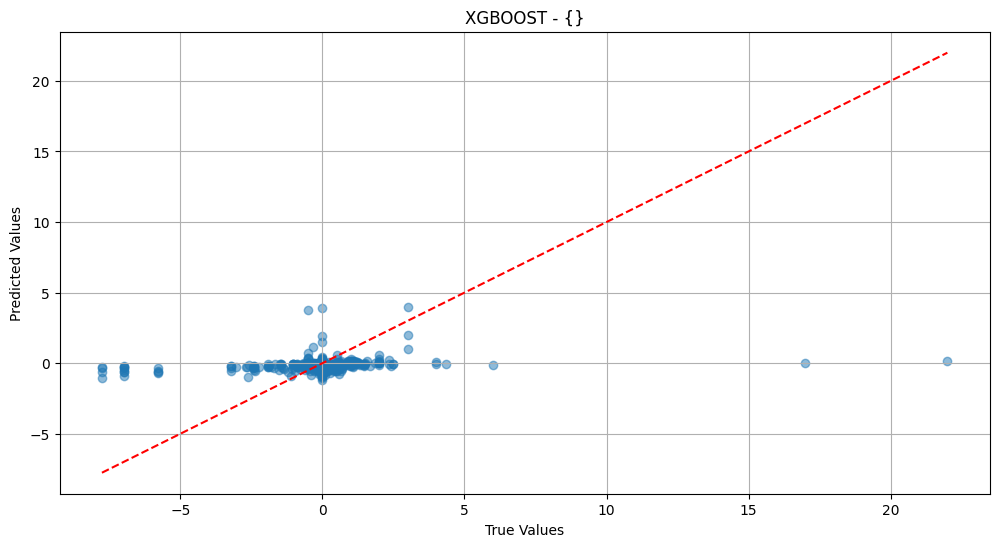


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: LSS: 100%|██████████| 3/3 [00:08<00:00,  2.76s/it]
 25%|██▌       | 1/4 [00:17<00:51, 17.27s/it]

Training completed for xgboost - {} in 7.45 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: LSS with ML config: {'model_type': 'xgboost'}



Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: WCA:   0%|          | 0/1 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}
Starting neural_network training with config: {}


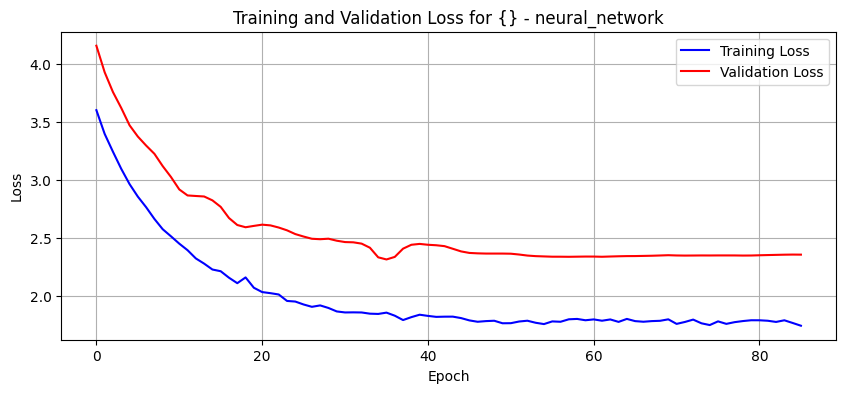


Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: WCA: 100%|██████████| 1/1 [00:08<00:00,  8.70s/it]


Training completed for neural_network - {} in 8.69 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}



Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCA:   0%|          | 0/3 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with ML config: {'model_type': 'random_forest'}
Starting random_forest training with config: {}
RANDOM_FOREST - {} - MSE: 2.3855935808301956, MAE: 0.9002909991143537, R²: -0.07950652863147718


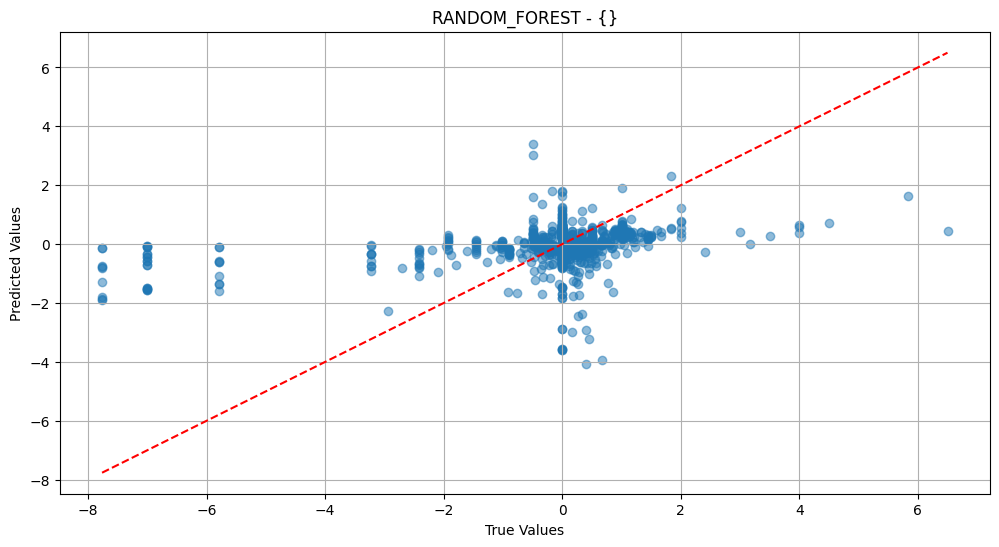


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCA:  33%|███▎      | 1/3 [00:00<00:01,  1.48it/s]

Training completed for random_forest - {} in 0.68 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with ML config: {'model_type': 'random_forest'}
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with ML config: {'model_type': 'decision_tree'}
Starting decision_tree training with config: {}
DECISION_TREE - {} - MSE: 3.165141002054499, MAE: 0.9312586185825599, R²: -0.6615947409493


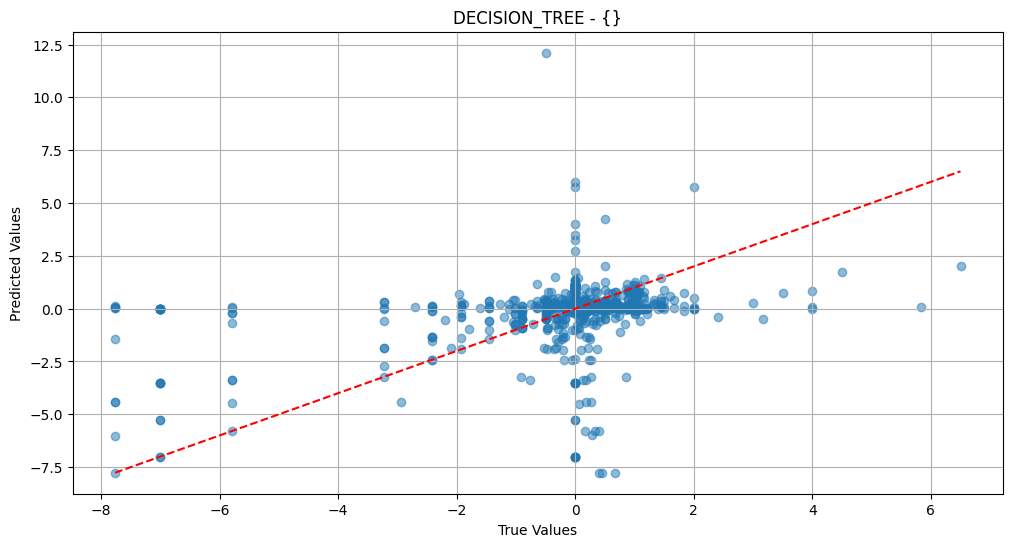


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCA:  67%|██████▋   | 2/3 [00:00<00:00,  2.29it/s]

Training completed for decision_tree - {} in 0.26 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with ML config: {'model_type': 'decision_tree'}
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with ML config: {'model_type': 'xgboost'}
Starting xgboost training with config: {}
XGBOOST - {} - MSE: 2.3444848130365212, MAE: 0.8412986789764251, R²: -0.11870347814619227


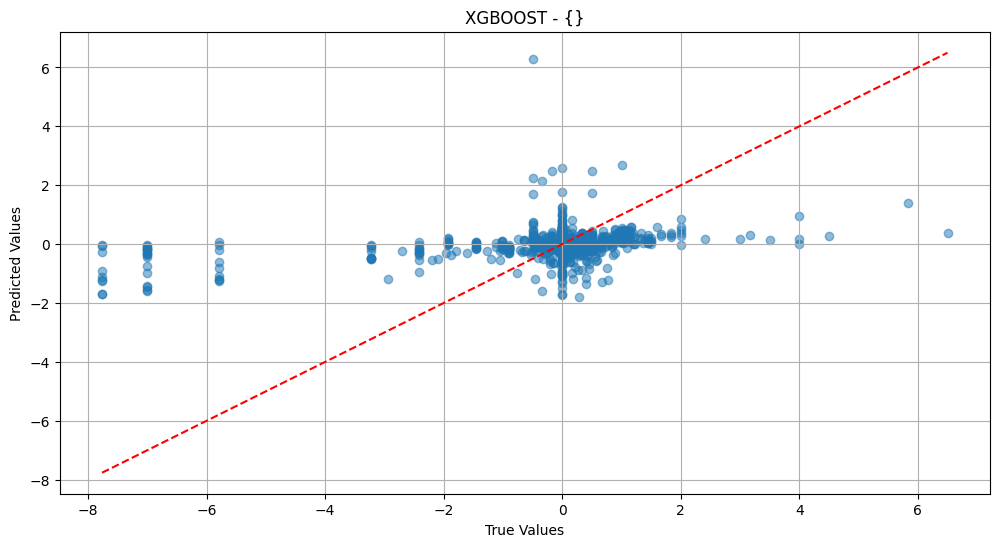


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCA: 100%|██████████| 3/3 [00:20<00:00,  6.96s/it]
 50%|█████     | 2/4 [00:46<00:49, 24.52s/it]

Training completed for xgboost - {} in 19.93 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with ML config: {'model_type': 'xgboost'}



Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: JMS:   0%|          | 0/1 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: JMS with config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}
Starting neural_network training with config: {}


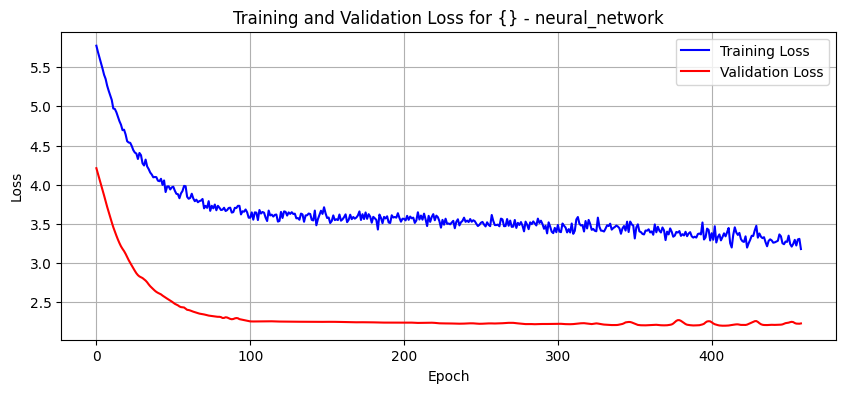


Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: JMS: 100%|██████████| 1/1 [00:28<00:00, 28.23s/it]


Training completed for neural_network - {} in 28.23 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: JMS with config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}



Training ML models for BasinTC: Midland, FORMATION_CONDENSED: JMS:   0%|          | 0/3 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: JMS with ML config: {'model_type': 'random_forest'}
Starting random_forest training with config: {}
RANDOM_FOREST - {} - MSE: 2.7438443317358443, MAE: 1.110451606417388, R²: -0.4762519547871651


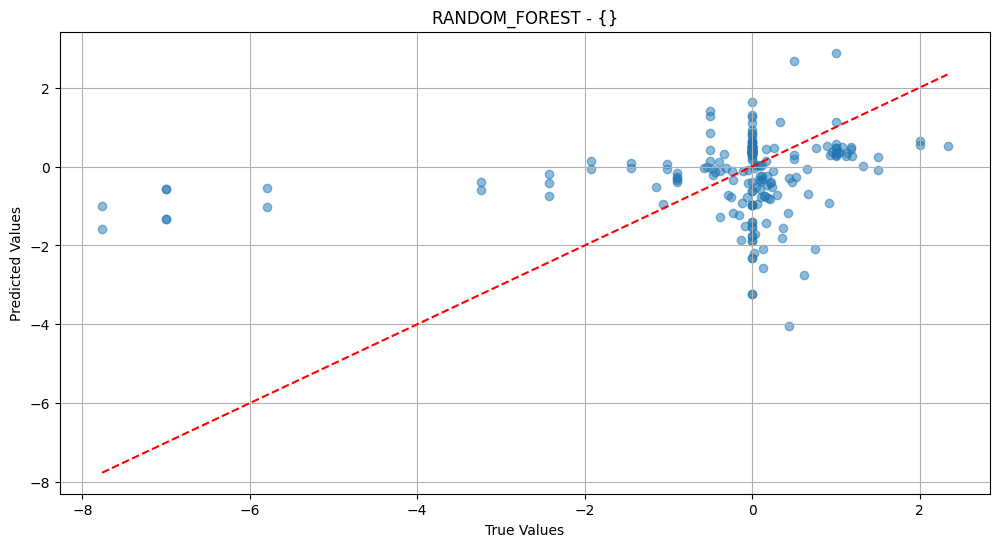


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: JMS:  33%|███▎      | 1/3 [00:00<00:00,  2.86it/s]

Training completed for random_forest - {} in 0.35 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: JMS with ML config: {'model_type': 'random_forest'}
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: JMS with ML config: {'model_type': 'decision_tree'}
Starting decision_tree training with config: {}
DECISION_TREE - {} - MSE: 4.276402497459895, MAE: 1.1525290349597541, R²: -1.3236399731233075


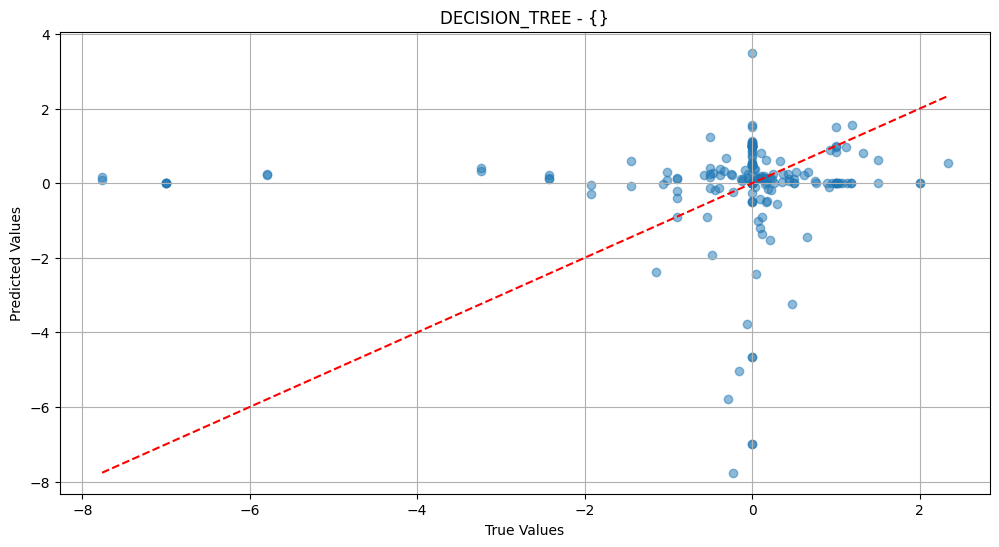


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: JMS:  67%|██████▋   | 2/3 [00:00<00:00,  4.08it/s]

Training completed for decision_tree - {} in 0.17 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: JMS with ML config: {'model_type': 'decision_tree'}
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: JMS with ML config: {'model_type': 'xgboost'}
Starting xgboost training with config: {}
XGBOOST - {} - MSE: 2.395791428297629, MAE: 0.7438629884309498, R²: -0.22434822369466378


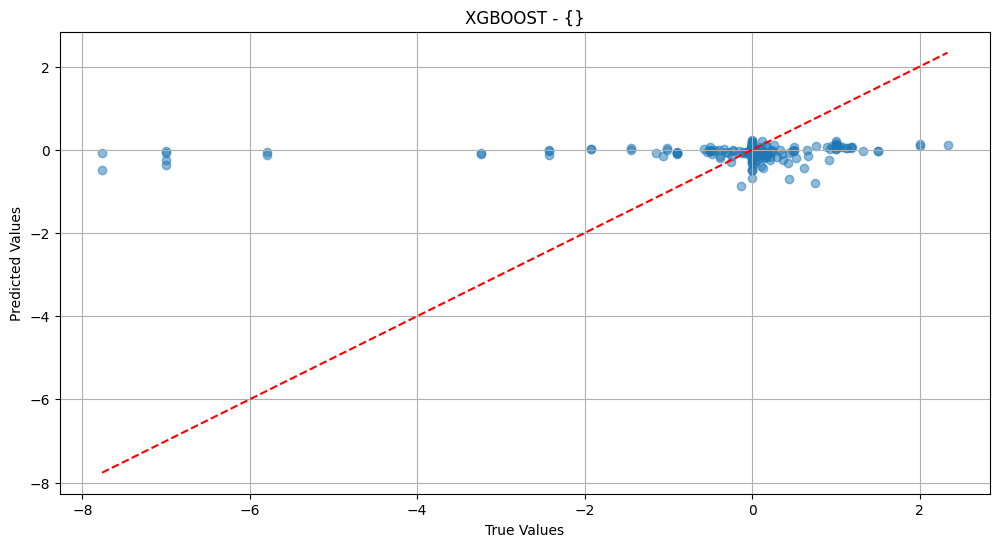


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: JMS: 100%|██████████| 3/3 [00:02<00:00,  1.45it/s]
 75%|███████▌  | 3/4 [01:17<00:27, 27.17s/it]

Training completed for xgboost - {} in 1.55 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: JMS with ML config: {'model_type': 'xgboost'}



Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: WCB:   0%|          | 0/1 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCB with config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}
Starting neural_network training with config: {}


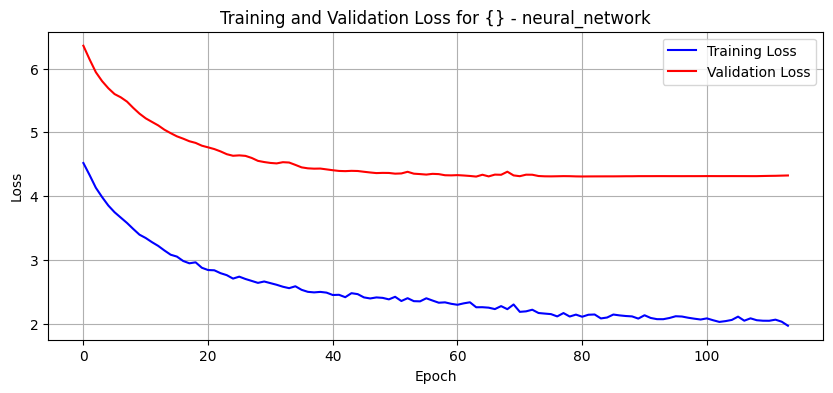


Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: WCB: 100%|██████████| 1/1 [00:09<00:00,  9.83s/it]


Training completed for neural_network - {} in 9.83 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCB with config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}



Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCB:   0%|          | 0/3 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCB with ML config: {'model_type': 'random_forest'}
Starting random_forest training with config: {}
RANDOM_FOREST - {} - MSE: 4.424416171972045, MAE: 0.9960194122299835, R²: -0.06231041828135112


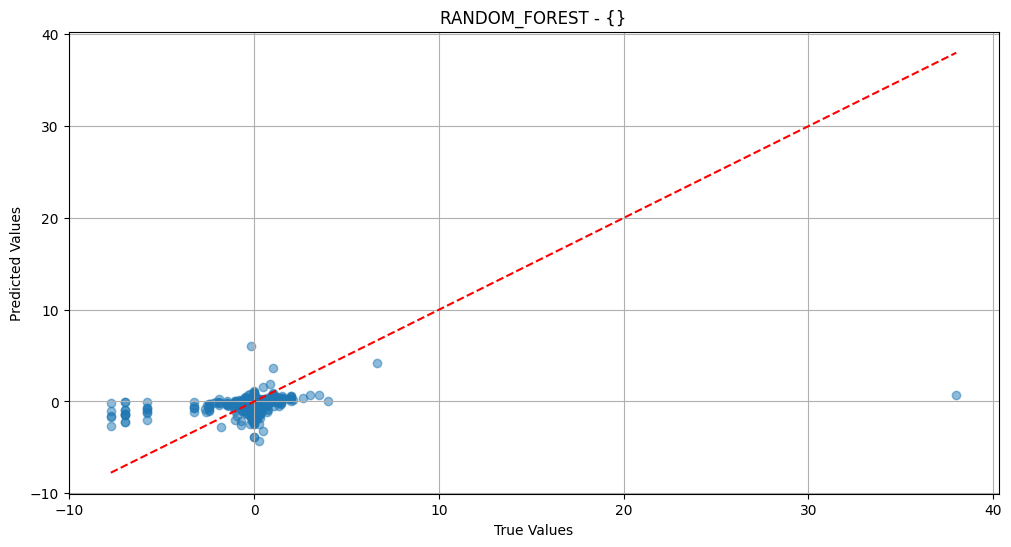


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCB:  33%|███▎      | 1/3 [00:00<00:01,  1.14it/s]

Training completed for random_forest - {} in 0.87 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCB with ML config: {'model_type': 'random_forest'}
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCB with ML config: {'model_type': 'decision_tree'}
Starting decision_tree training with config: {}
DECISION_TREE - {} - MSE: 5.9313295642290775, MAE: 1.0541231767176953, R²: -0.6483058614753124


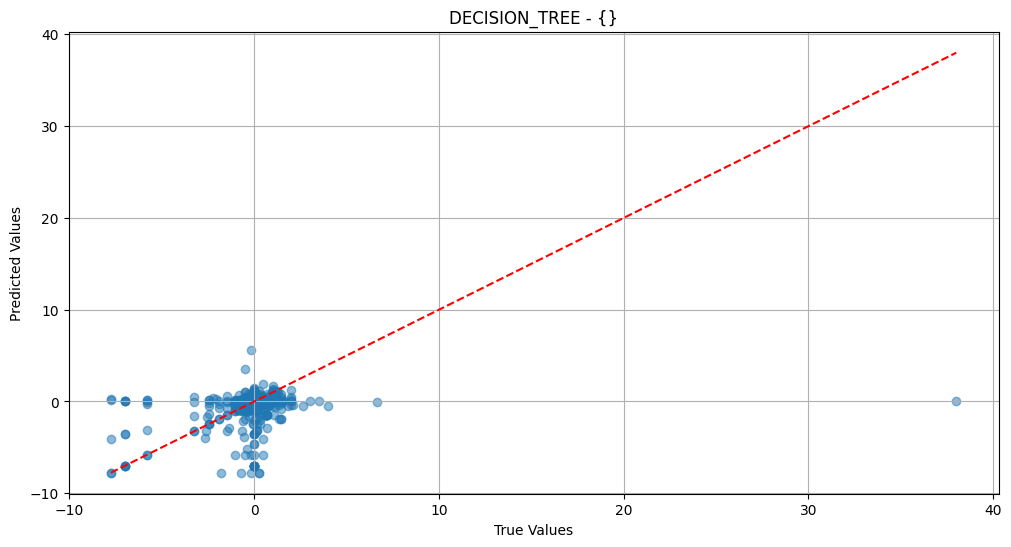


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCB:  67%|██████▋   | 2/3 [00:01<00:00,  2.07it/s]

Training completed for decision_tree - {} in 0.21 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCB with ML config: {'model_type': 'decision_tree'}
Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCB with ML config: {'model_type': 'xgboost'}
Starting xgboost training with config: {}
XGBOOST - {} - MSE: 4.1193938354925415, MAE: 0.9213799882861916, R²: 0.01269677621703987


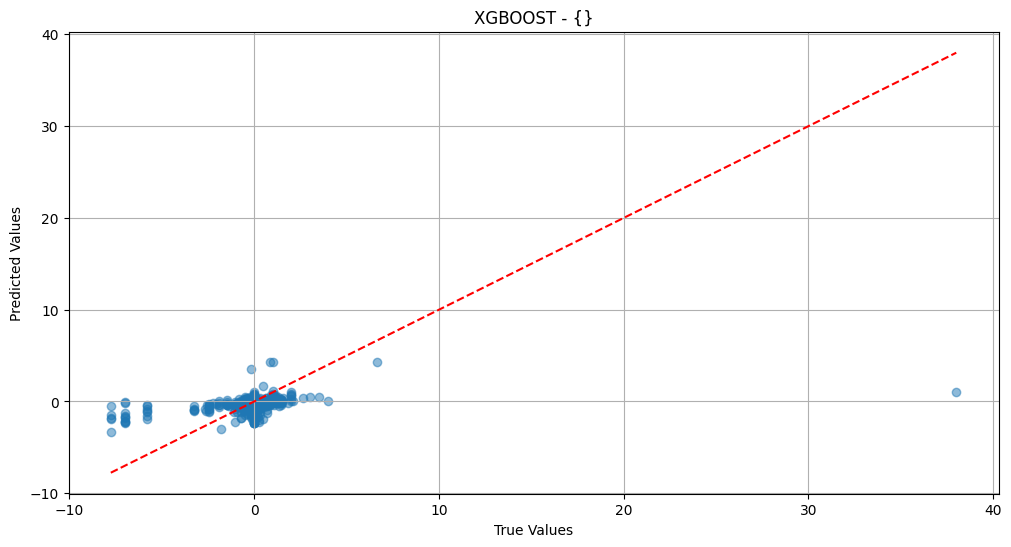


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCB: 100%|██████████| 3/3 [00:24<00:00,  8.31s/it]
100%|██████████| 4/4 [01:51<00:00, 27.99s/it]

Training completed for xgboost - {} in 23.85 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCB with ML config: {'model_type': 'xgboost'}


In [54]:
# Dictionary to store task times
task_times = {}

# Execution
models = execute_training(
    specific_combinations, train_df, val_df, test_df, numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode='serial'  # Change mode to 'serial' for serial execution
)


In [55]:
# Compute SHAP values
#shap_values_dict = compute_and_log_shap_values(models, test_df, numerical_columns, categorical_columns, shap_sample_size=100)
# Print out the task times to identify slow tasks
print("Task times (in seconds):")
for task, duration in task_times.items():
    print(f"{task}: {duration:.2f} seconds")

Task times (in seconds):
neural_network - {}: 9.83 seconds
random_forest - {}: 0.87 seconds
decision_tree - {}: 0.21 seconds
xgboost - {}: 23.85 seconds


In [56]:
# # Define the variables
# basin = 'Midland'
# #formation = 'WCA'
# formation = ['LSS', 'WCA', 'WCB', 'WCD']
# config_str = "{'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128, 64, 32], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x0000024A7D101640>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}"
# feature_names = numerical_columns + categorical_columns  # Ensure this list contains all your feature names
# output_pdf = r"C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\shap_summary_plot.pdf"

# # Plot the SHAP values
# plot_shap_values(shap_values_dict, y_headers, feature_names, output_pdf)

In [57]:
# Function to denormalize numerical data
def denormalize_data_input(data, scaler):
    return scaler.inverse_transform(data)
# Function to denormalize data and revert log transformation
def denormalize_data_output(data, scaler, log_transform_columns):
    denormalized_data = scaler.inverse_transform(data)
    denormalized_df = pd.DataFrame(denormalized_data, columns=scaler.get_feature_names_out())
    denormalized_df[log_transform_columns] = np.expm1(denormalized_df[log_transform_columns])
    if any('BuildupRate' in col for col in log_transform_columns):
        denormalized_df[log_transform_columns] = denormalized_df[log_transform_columns].replace(1, 0)
    return denormalized_df
# Function to decode categorical data
def decode_categorical(data, encoders, column_names):
    decoded_data = {}
    for i, col in enumerate(column_names):
        le = encoders[col]
        decoded_data[col] = le.inverse_transform(data[:, i].astype(int))
    return decoded_data
# Denormalize and decode the training DataFrame
def denormalize_and_decode(train_df, numerical_columns, categorical_columns, y_headers, input_scaler, output_scaler, encoders):
    # Denormalize numerical features
    train_df[numerical_columns] = denormalize_data_input(train_df[numerical_columns], input_scaler)
    #log_transform_columns = [col for col in y_headers if 'BuildupRate' in col or 'InitialProd' in col]
    log_transform_columns = [col for col in y_headers if 'InitialProd' in col]
    # Denormalize target features
    train_df[y_headers] = denormalize_data_output(train_df[y_headers], output_scaler, log_transform_columns)
    # Decode categorical features
    decoded_categorical = decode_categorical(train_df, encoders, categorical_columns)
    for col in categorical_columns:
        train_df[col] = decoded_categorical[col]
    return train_df

In [58]:
# Function to generate hyperbolic decline curve
def hyperbolic_decline(t, qi, di, b):
    return qi / ((1 + b * di * t) ** (1 / b))

def modified_hyperbolic(time, qi, di, b, Dlim, IBU, MBU, buildup_method='Linear', epsilon=1e-10):
    """
    Calculate the production rate using the Modified Hyperbolic Decline Model with a buildup phase.
    """
    # Convert decline rates to nominal rates
    di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
    Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)

    # Handle potential division by zero
    if di == 0 or Dlim == 0:
        return np.zeros_like(time)

    # Calculate switch point
    qlim = qi * (Dlim / di) ** (1.0 / b)
    tlim = ((qi / qlim) ** b - 1.0) / (b * di)

    # Separate time into buildup, hyperbolic, and exponential segments
    t_buildup = time[time <= MBU]
    t_post_buildup = time[time > MBU]
    t_hyp = t_post_buildup[t_post_buildup < tlim]
    t_exp = t_post_buildup[t_post_buildup >= tlim]

    # Calculate production during buildup period
    if buildup_method == 'Flat':
        buildup_production = IBU + np.zeros_like(t_buildup)
    elif buildup_method == 'Linear':
        slope = (qi - IBU) / (MBU + epsilon)
        buildup_production = IBU + slope * t_buildup
    elif buildup_method == 'Exp':
        slope = np.log(qi / (IBU + epsilon)) / (MBU + epsilon)
        buildup_production = IBU * np.exp(slope * t_buildup)
    else:
        raise ValueError("Unknown buildup method: {}".format(buildup_method))

    # Calculate production during hyperbolic decline period
    q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)

    # Calculate production during exponential decline period
    q_model_exp = qlim * np.exp(-Dlim * (t_exp - tlim))

    # Combine production rates
    production_post_buildup = np.concatenate((q_model_hyp, q_model_exp))
    production = np.concatenate((buildup_production, production_post_buildup))

    return production

def generate_production_rates(y_pred_denormalized, y_true_denormalized, headers, time):
    predicted_productions = []
    actual_productions = []

    for idx in range(len(y_pred_denormalized)):
        qi_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_InitialProd')]
        di_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_DiCoefficient')]
        b_pred  = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_BCoefficient')]
        IBU_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_BuildupRate')]
        MBU_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_MonthsInProd')]
        Dlim_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_LimDeclineRate')]
        
        qi_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_InitialProd')]
        di_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_DiCoefficient')]
        b_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_BCoefficient')]
        IBU_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_BuildupRate')]
        MBU_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_MonthsInProd')]
        Dlim_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_LimDeclineRate')]
        
        predicted_production = modified_hyperbolic(time, qi_pred, di_pred, b_pred, Dlim_pred, IBU_pred, MBU_pred)
        actual_production = modified_hyperbolic(time, qi_true, di_true, b_true, Dlim_true, IBU_true, MBU_true)
        
        # Ensure lengths are the same
        if len(predicted_production) == len(actual_production):
            predicted_productions.append(predicted_production)
            actual_productions.append(actual_production)

    return predicted_productions, actual_productions

def calculate_errors(predicted_productions, actual_productions):
    errors = {
        'MSE': [],
        'MAE': [],
        'sMAPE': []
    }

    for pred, actual in zip(predicted_productions, actual_productions):
        if len(pred) != len(actual):
            print(f"Length mismatch: predicted={len(pred)}, actual={len(actual)}")
            continue
        
        mse = mean_squared_error(actual, pred)
        mae = mean_absolute_error(actual, pred)
        smape = np.mean(np.abs(pred - actual) / ((np.abs(actual) + np.abs(pred)) / 2)) * 100
        
        errors['MSE'].append(mse)
        errors['MAE'].append(mae)
        errors['sMAPE'].append(smape)

    return errors

def identify_best_worst_matches(errors, y_true_denormalized, y_pred_denormalized):
    best_match_idx = np.argmin(errors)
    worst_match_idx = np.argmax(errors)

    best_match_true = y_true_denormalized.iloc[best_match_idx]
    best_match_pred = y_pred_denormalized.iloc[best_match_idx]

    worst_match_true = y_true_denormalized.iloc[worst_match_idx]
    worst_match_pred = y_pred_denormalized.iloc[worst_match_idx]

    return best_match_true, best_match_pred, worst_match_true, worst_match_pred, best_match_idx, worst_match_idx

def plot_decline_curves(time, actual, predicted, title):
    plt.figure(figsize=(10, 6))
    # Ensure lengths are the same for plotting
    min_len = min(len(time), len(actual), len(predicted))
    plt.plot(time[:min_len], actual[:min_len], 'b-o', label='Actual')
    plt.plot(time[:min_len], predicted[:min_len], 'r--x', label='Predicted')
    plt.yscale('log')
    plt.ylim(1, 100000)
    plt.title(title)
    plt.xlabel('Time (Months)')
    plt.ylabel('Production Rate (bbl/day)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--')
    plt.show()

In [59]:
# Define the prediction function
#@tf.function(reduce_retracing=True)
def predict_with_model(model, numerical_data, categorical_data):
    if isinstance(model, Model):  # Keras model
        return model.predict([numerical_data] + categorical_data)
    else:  # Sklearn model
        import pandas as pd
        data_combined = np.hstack([numerical_data] + categorical_data)
        combined_df = pd.DataFrame(data_combined, columns=numerical_columns + categorical_columns)
        return model.predict(combined_df)

In [60]:
def combine_data(numerical_data, categorical_data):
    if categorical_data:  # Check if categorical_data is not empty
        categorical_data_combined = np.hstack([cat for cat in categorical_data])
        combined_data = np.hstack((numerical_data, categorical_data_combined))
    else:
        combined_data = numerical_data
    return combined_data

def sensitivity_analysis(cov_matrix, model, numerical_columns, categorical_columns, combo_val, time, y_headers, y_true_denormalized, y_pred_denormalized, output_scaler, log_transform_columns):
    combined_val_data = combine_data(combo_val[numerical_columns].values, 
                                     [combo_val[col].astype(int).values.reshape(-1, 1) for col in categorical_columns])
    sensitivities = []
    feature_names = numerical_columns + categorical_columns

    # Debugging: Print the shape of combined_val_data
    print(f"Shape of combined_val_data: {combined_val_data.shape}")

    for i, feature in enumerate(feature_names):
        perturbed_data = combined_val_data.copy()
        perturbed_data[:, i] += np.sqrt(cov_matrix[i, i])  # Perturb by one standard deviation

        # Predict using the model
        perturbed_numerical_data = perturbed_data[:, :len(numerical_columns)]
        perturbed_categorical_data = [perturbed_data[:, len(numerical_columns) + j].reshape(-1, 1) for j in range(len(categorical_columns))]
        y_pred_perturbed = predict_with_model(model, perturbed_numerical_data, perturbed_categorical_data)

        # Denormalize the predictions
        y_pred_perturbed_denormalized = denormalize_data_output(y_pred_perturbed, output_scaler, log_transform_columns)
        
        # Generate production rates
        predicted_productions_perturbed, _ = generate_production_rates(y_pred_perturbed_denormalized, y_true_denormalized, y_headers, time)

        # Calculate mean sensitivity (change in production rate)
        mean_sensitivity = np.mean(np.abs(np.array(predicted_productions_perturbed) - np.array(predicted_productions)), axis=0)
        sensitivities.append(mean_sensitivity)

    return sensitivities, feature_names

def plot_sensitivity_analysis(sensitivities, feature_names):
    plt.figure(figsize=(12, 6))
    plt.barh(feature_names, sensitivities)
    plt.xlabel('Mean Sensitivity')
    plt.ylabel('Input Features')
    plt.title('Sensitivity Analysis of Predicted Production Rates vs Input Features')
    plt.grid(True)
    plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


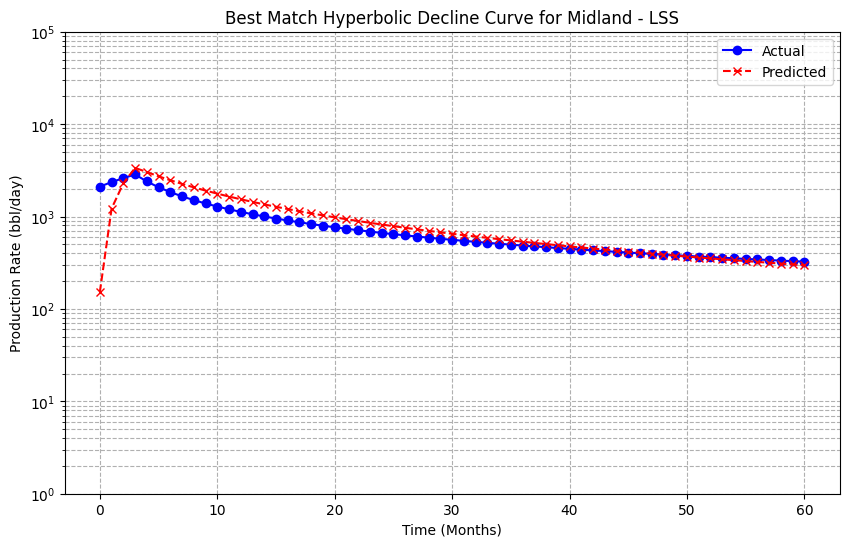

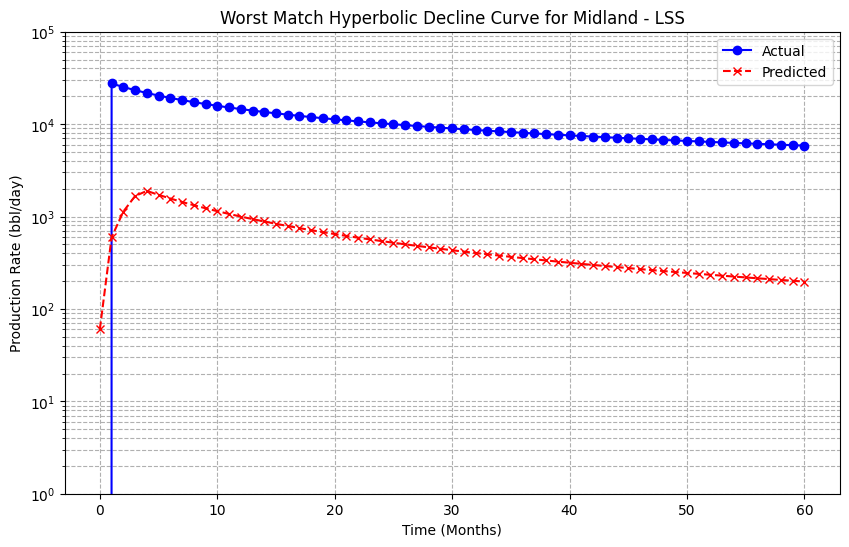

Performance for Basin: Midland, Formation: LSS, Config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'} - MSE: 320543890.1251, MAE: 6353.8615, sMAPE: 116.56%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


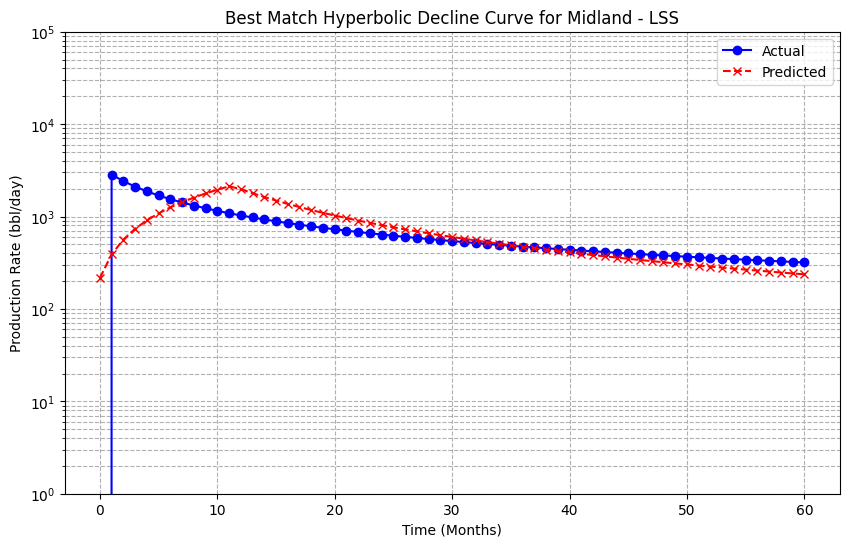

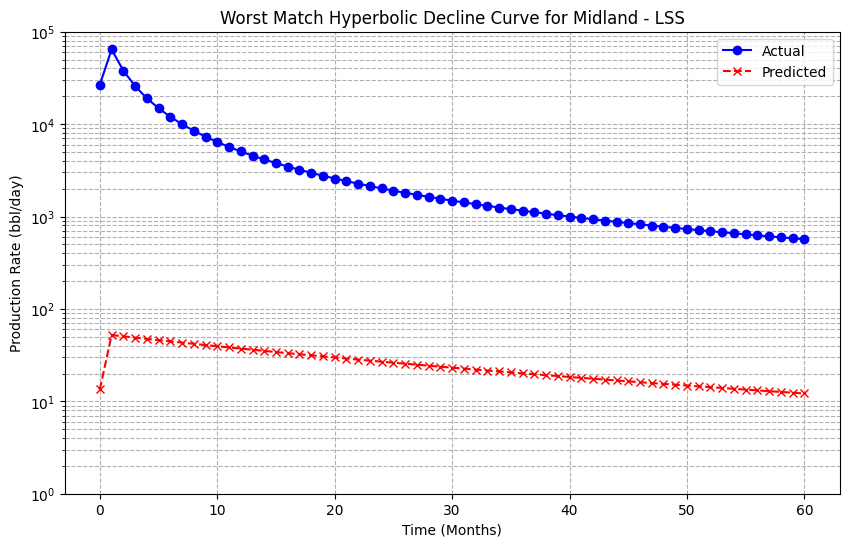

Performance for Basin: Midland, Formation: LSS, Config: random_forest - MSE: 327328315.0902, MAE: 6489.0953, sMAPE: 119.97%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:94: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(np.abs(pred - actual) / ((np.abs(actual) + np.abs(pred

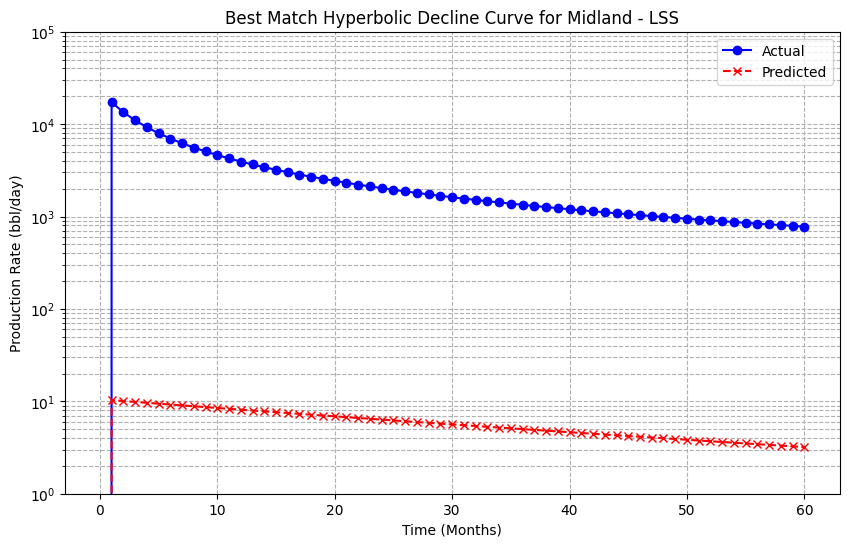

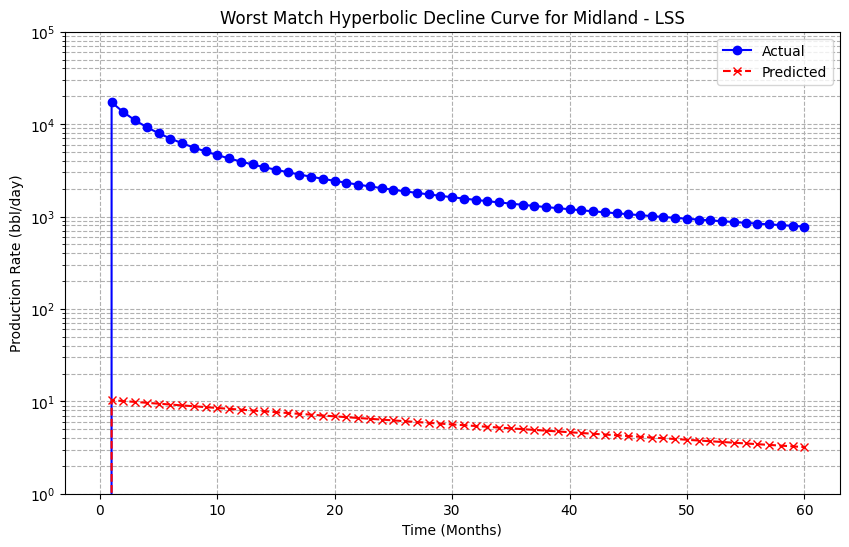

Performance for Basin: Midland, Formation: LSS, Config: decision_tree - MSE: 310619684.1220, MAE: 6560.0184, sMAPE: 109.30%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


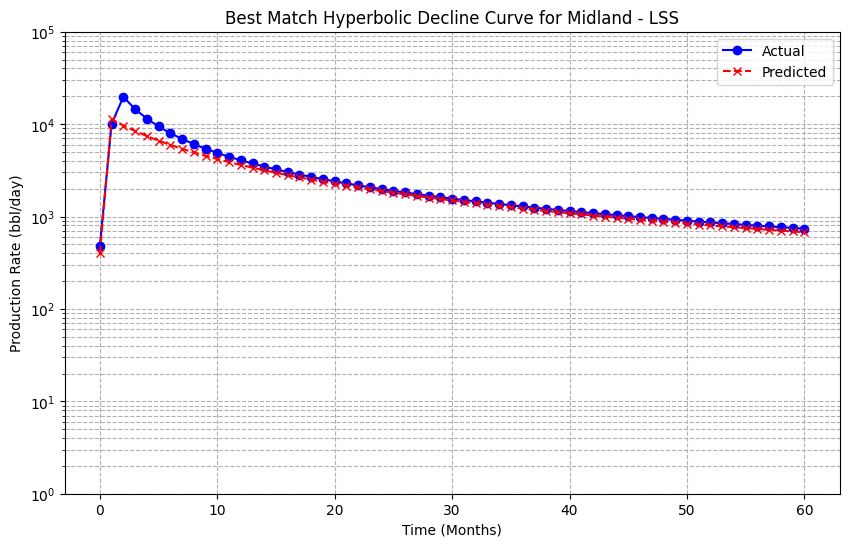

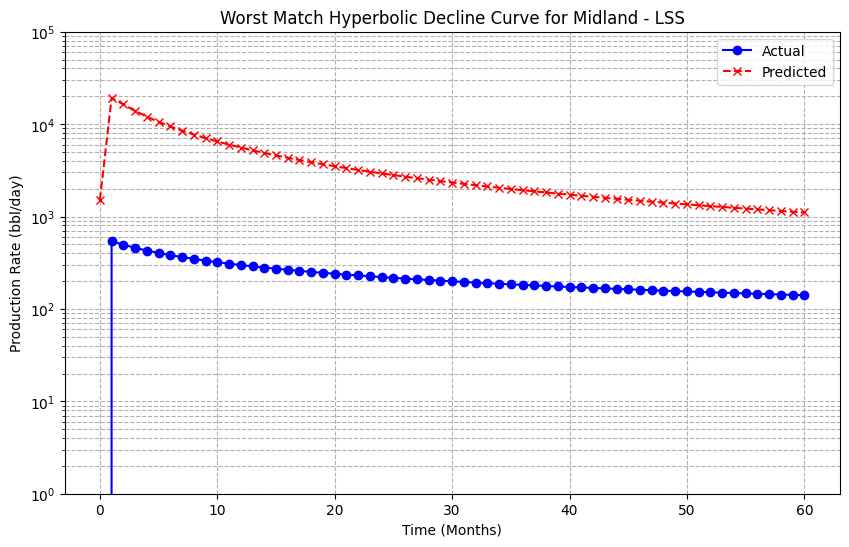

Performance for Basin: Midland, Formation: LSS, Config: xgboost - MSE: 297266328.9092, MAE: 6104.5030, sMAPE: 119.72%
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


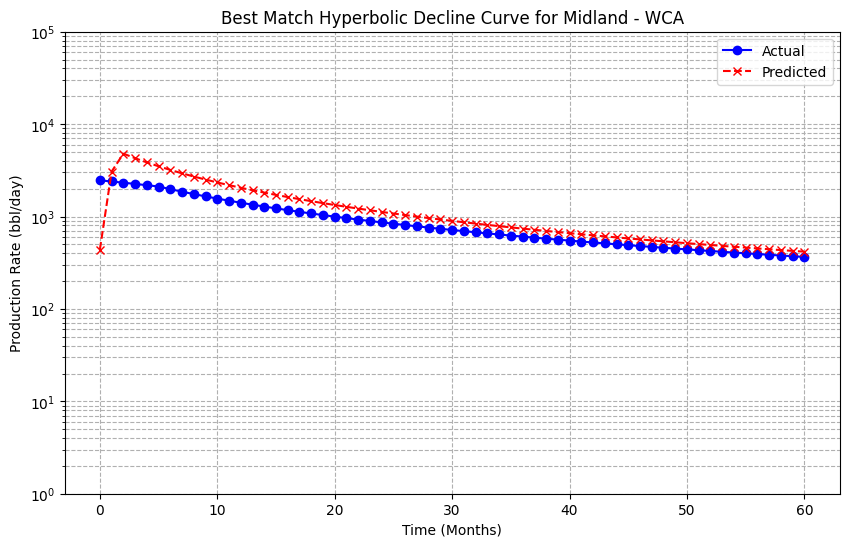

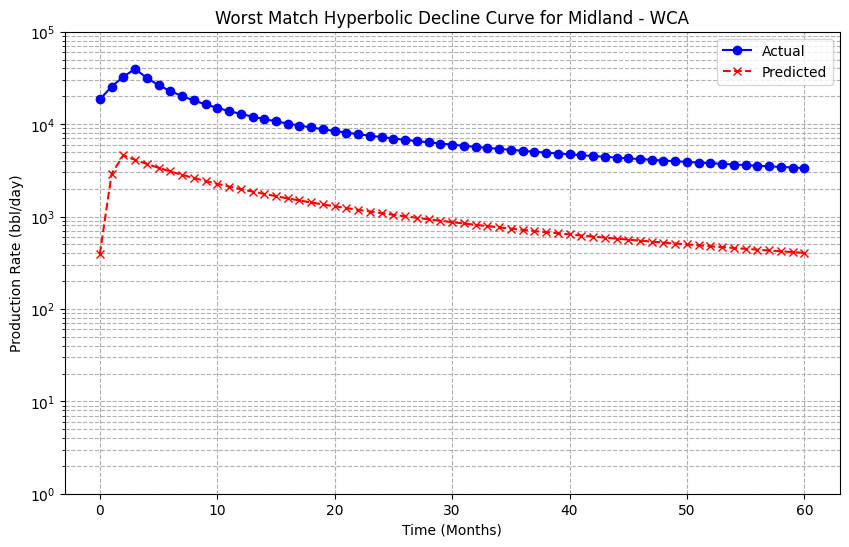

Performance for Basin: Midland, Formation: WCA, Config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'} - MSE: 122892600.5027, MAE: 3341.8114, sMAPE: 129.59%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


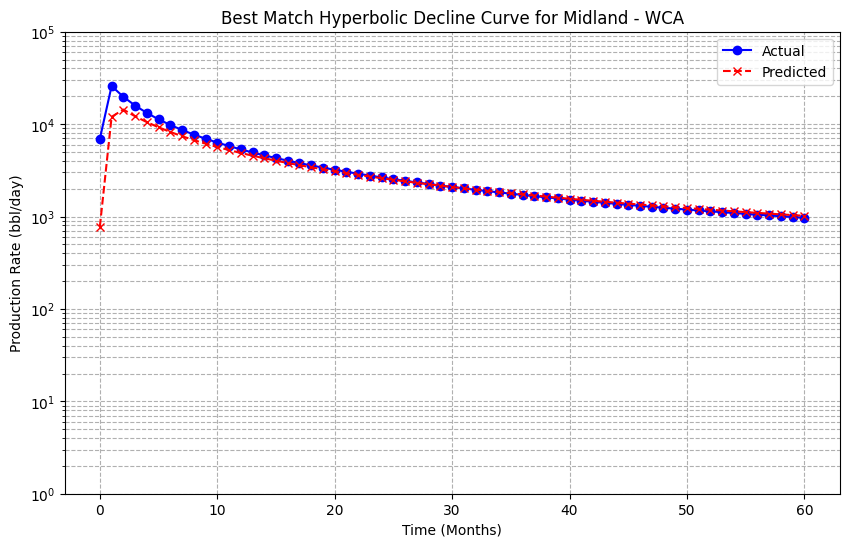

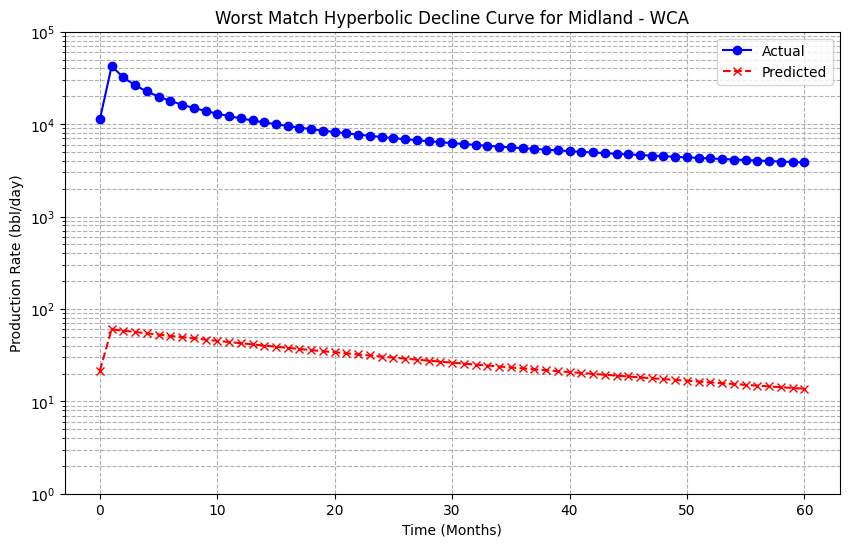

Performance for Basin: Midland, Formation: WCA, Config: random_forest - MSE: 118356922.7439, MAE: 3378.1165, sMAPE: 127.73%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


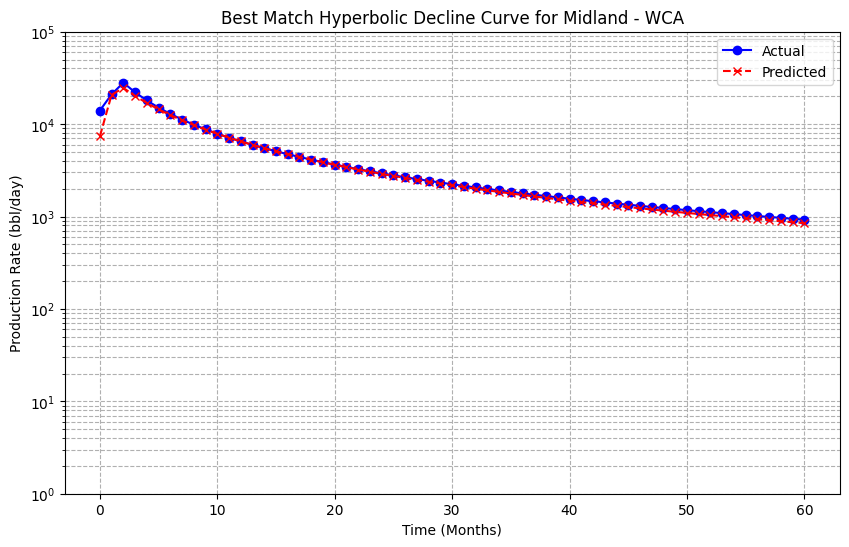

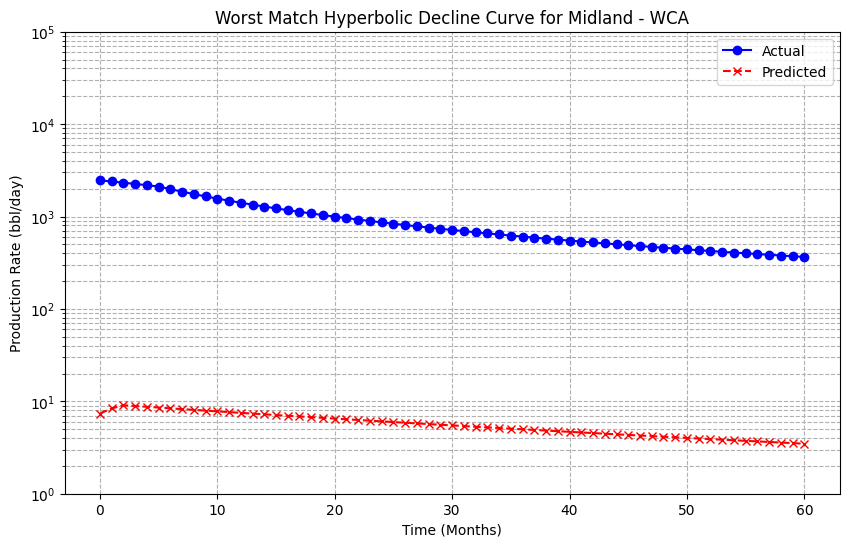

Performance for Basin: Midland, Formation: WCA, Config: decision_tree - MSE: 177878668.6792, MAE: 4456.8562, sMAPE: 123.04%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


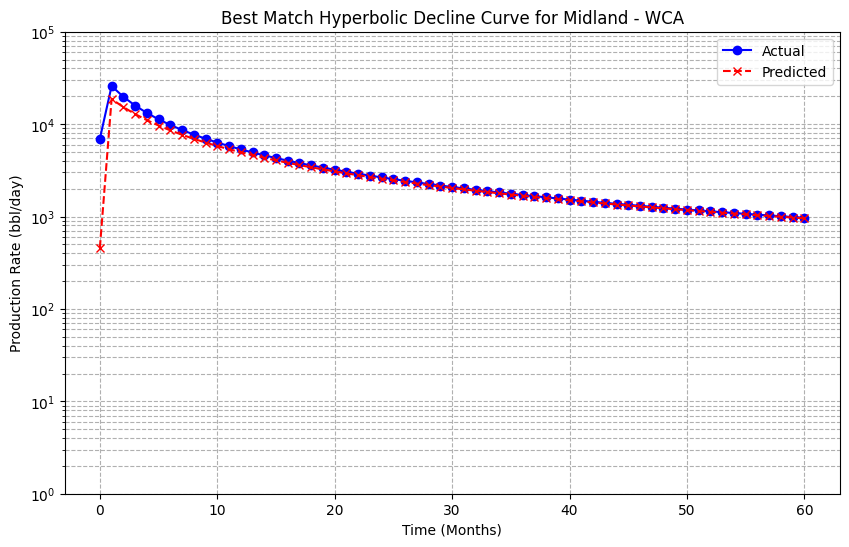

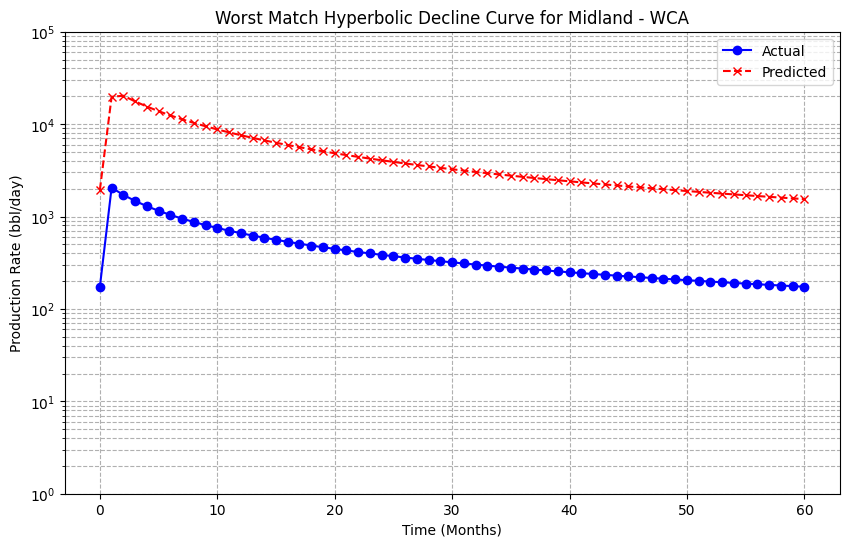

Performance for Basin: Midland, Formation: WCA, Config: xgboost - MSE: 119235395.6585, MAE: 3536.0804, sMAPE: 127.07%


2024-07-17 16:29:26,231 - WARNING - 5 out of the last 5 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002022558F1A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


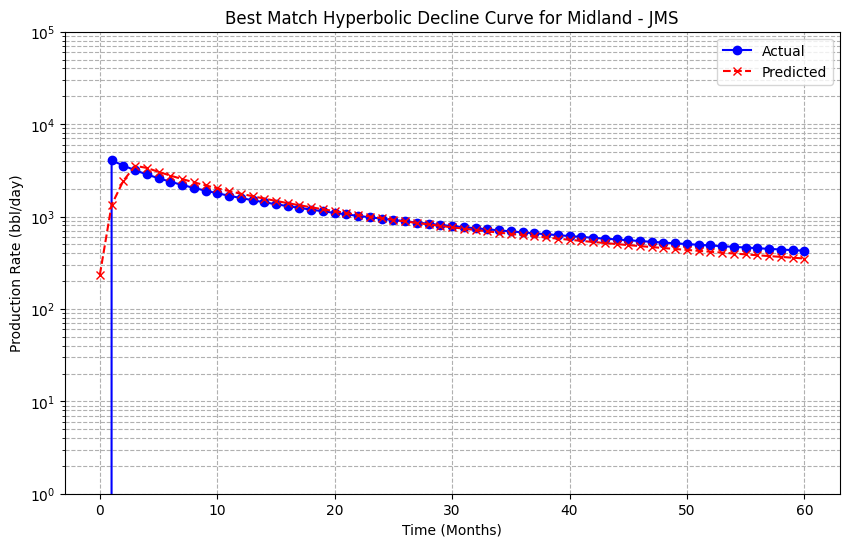

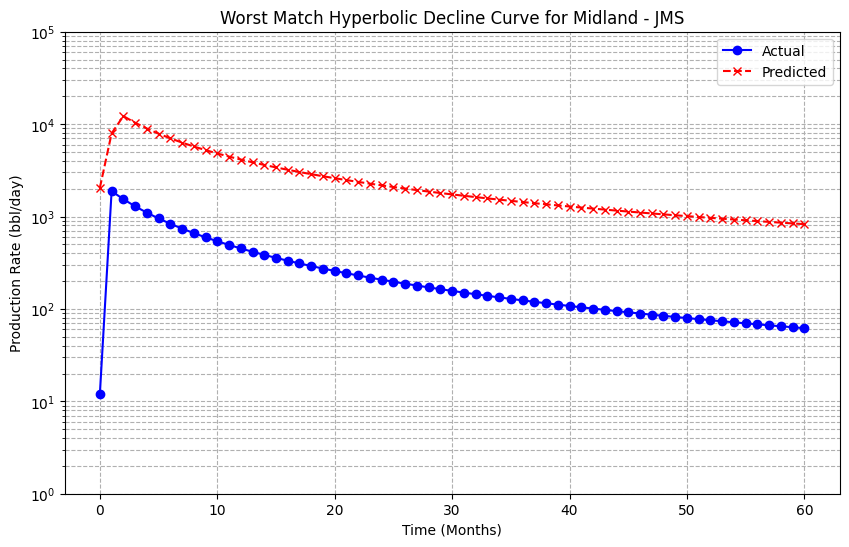

Performance for Basin: Midland, Formation: JMS, Config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'} - MSE: 255336216.3772, MAE: 5500.1824, sMAPE: 124.77%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


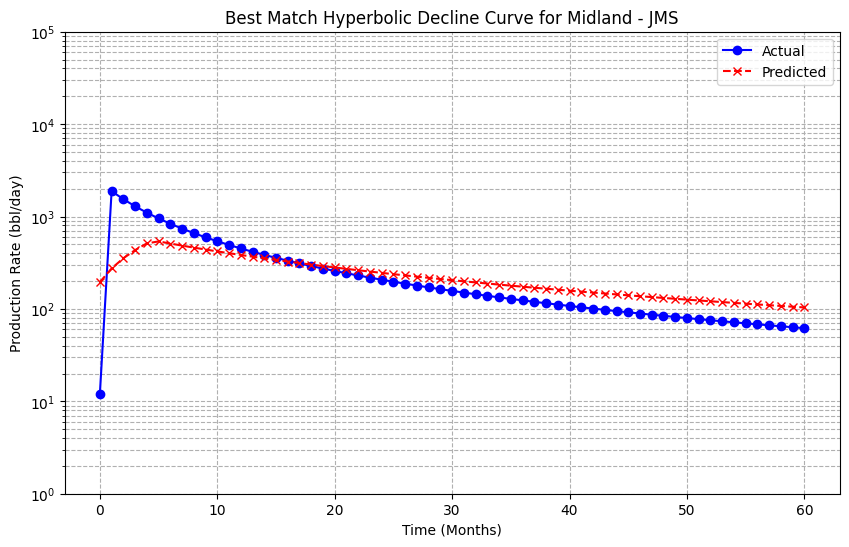

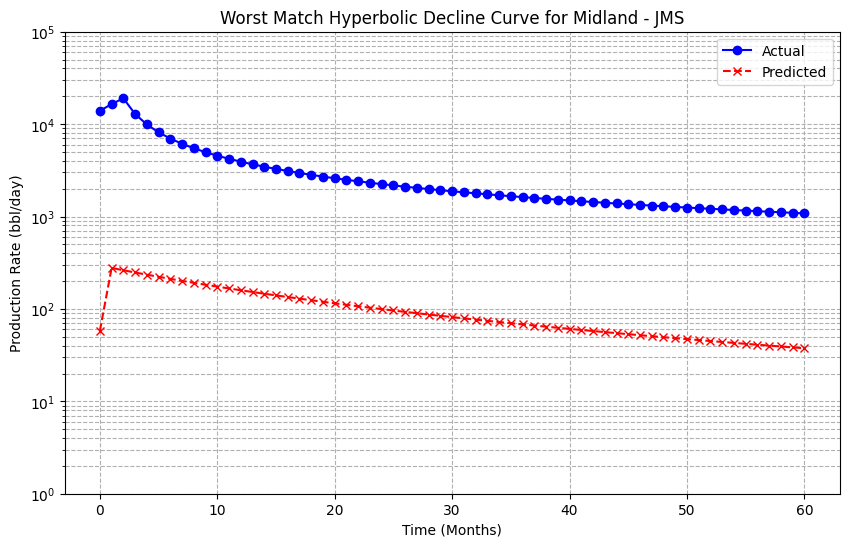

Performance for Basin: Midland, Formation: JMS, Config: random_forest - MSE: 271362621.6523, MAE: 5629.2925, sMAPE: 129.12%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


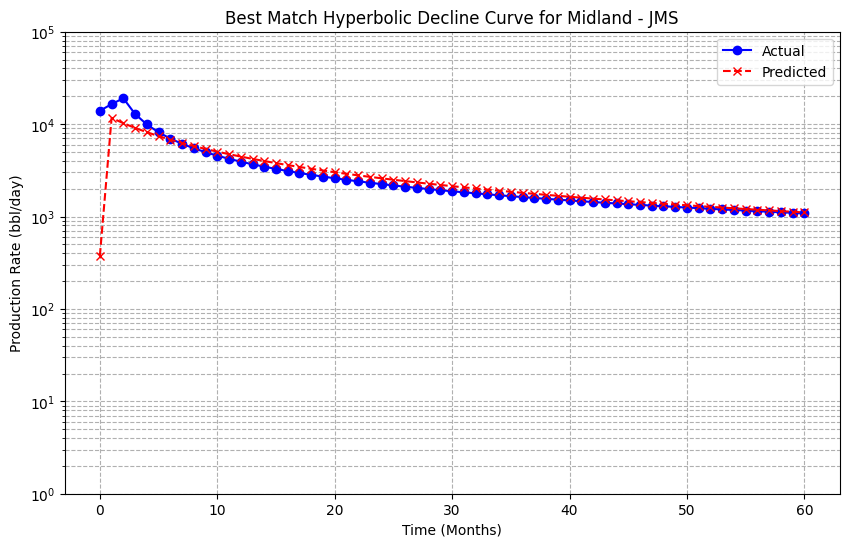

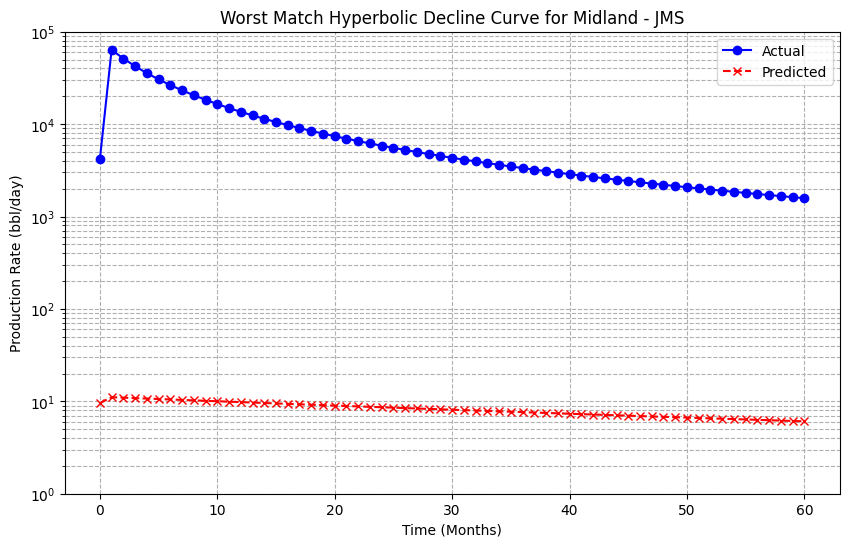

Performance for Basin: Midland, Formation: JMS, Config: decision_tree - MSE: 406676097.4003, MAE: 7892.0554, sMAPE: 123.29%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


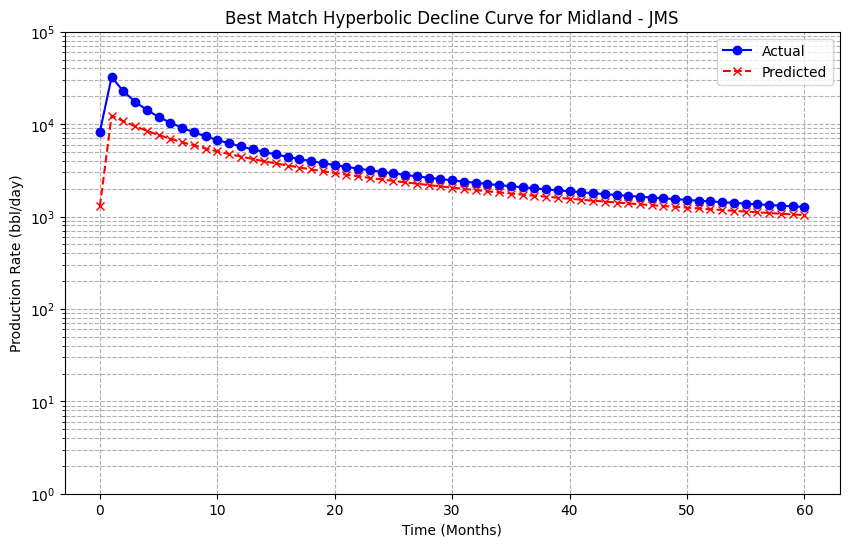

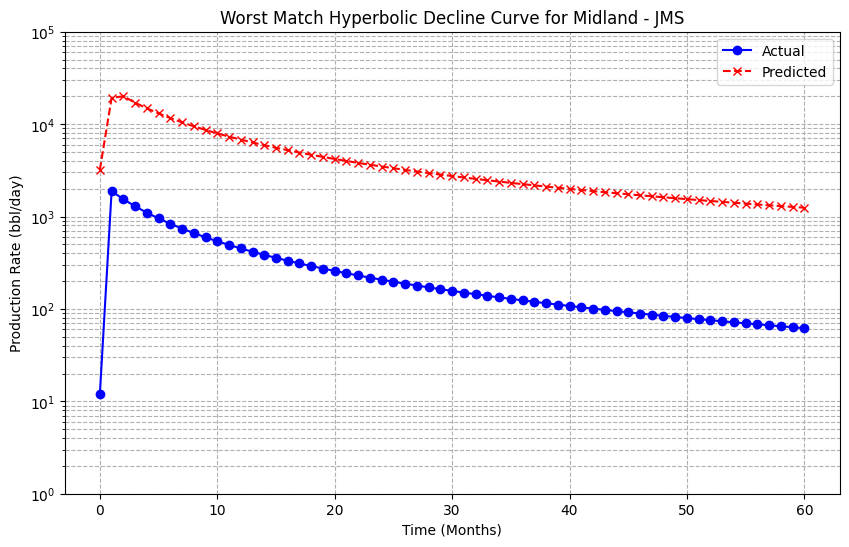

Performance for Basin: Midland, Formation: JMS, Config: xgboost - MSE: 212158665.8459, MAE: 5010.3678, sMAPE: 119.83%


2024-07-17 16:29:29,672 - WARNING - 6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000020231C44F40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


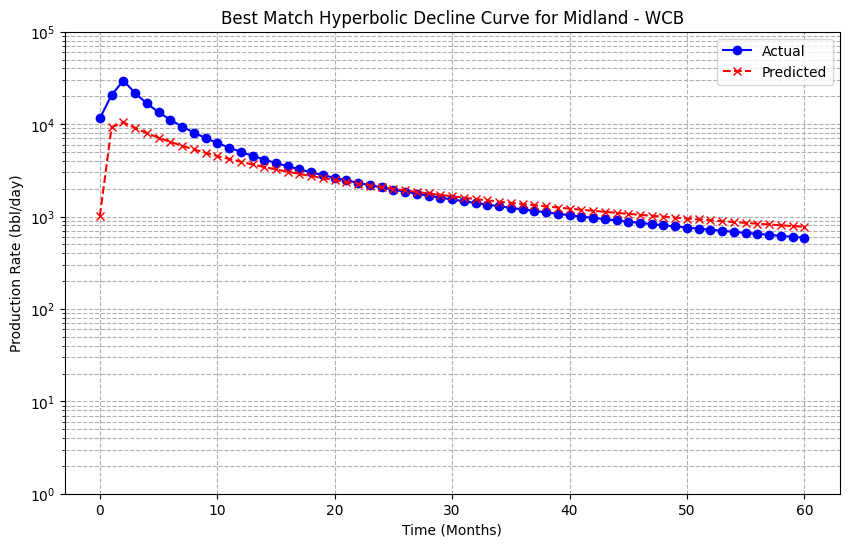

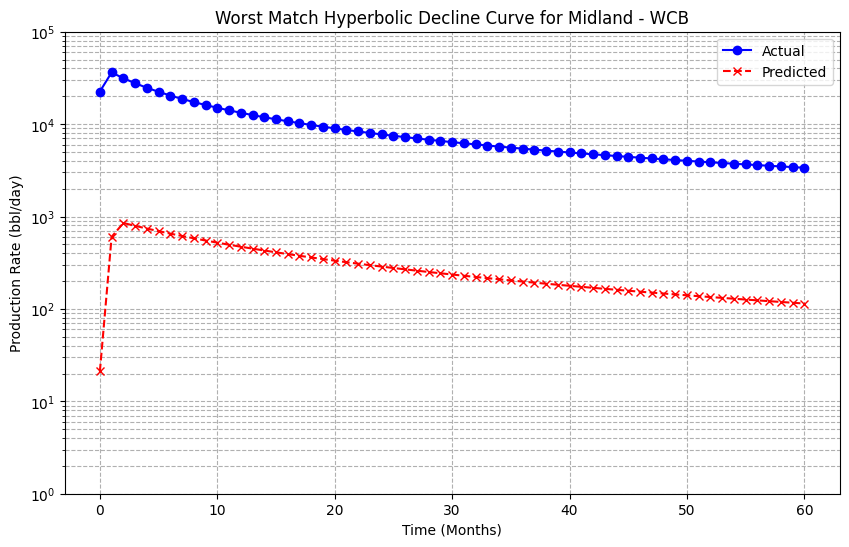

Performance for Basin: Midland, Formation: WCB, Config: {'embedding_output_dim': 10, 'dense_layer_sizes': [128, 32], 'dropout_rate': 0.2, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x00000202179BAB70>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'} - MSE: 309915309.3750, MAE: 5867.5363, sMAPE: 122.87%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


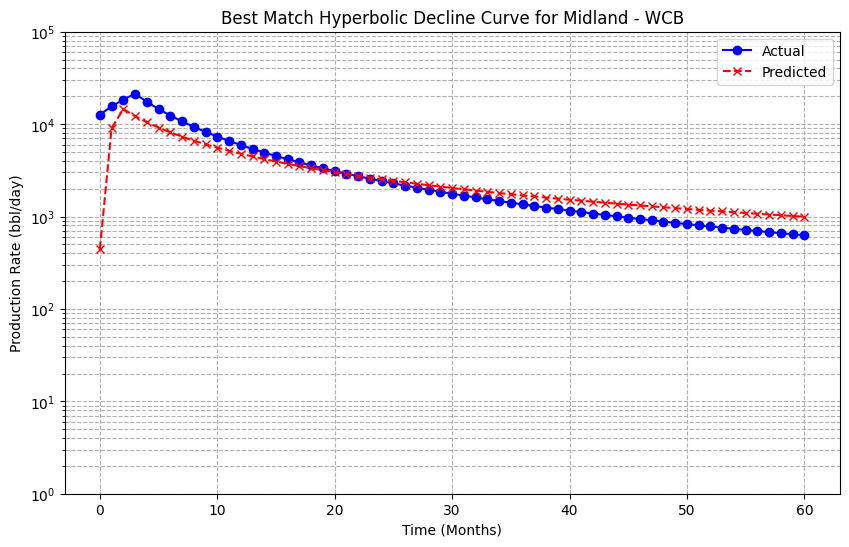

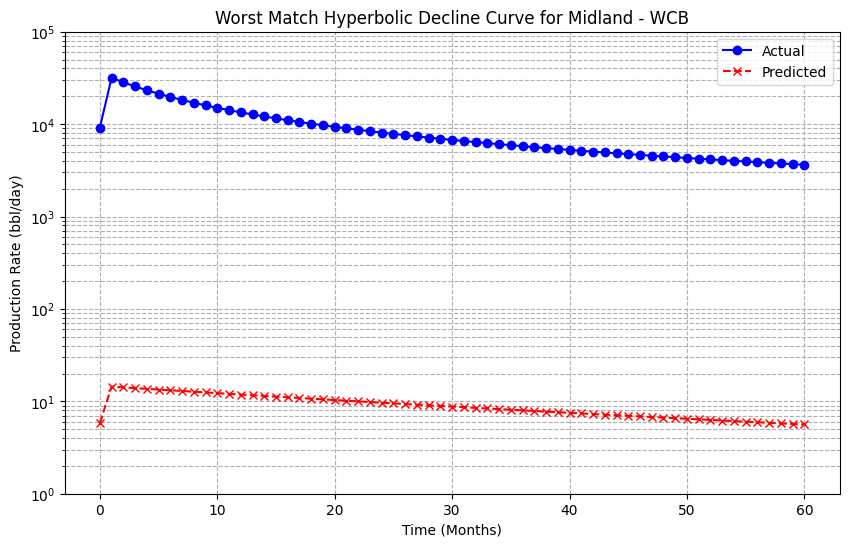

Performance for Basin: Midland, Formation: WCB, Config: random_forest - MSE: 312493469.0937, MAE: 5790.2575, sMAPE: 125.20%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:94: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(np.abs(pred - actual) / ((np.abs(actual) + np.abs(pred

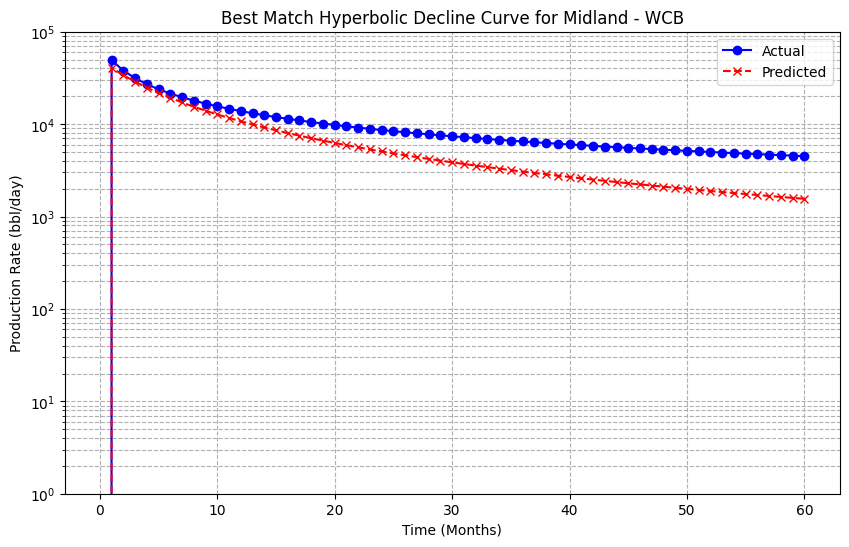

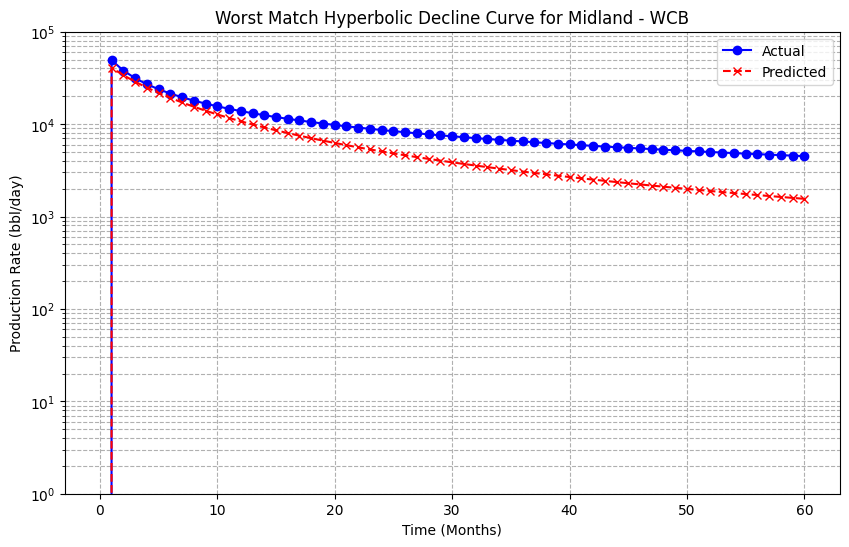

Performance for Basin: Midland, Formation: WCB, Config: decision_tree - MSE: 288301433.9832, MAE: 5864.4848, sMAPE: 122.54%


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


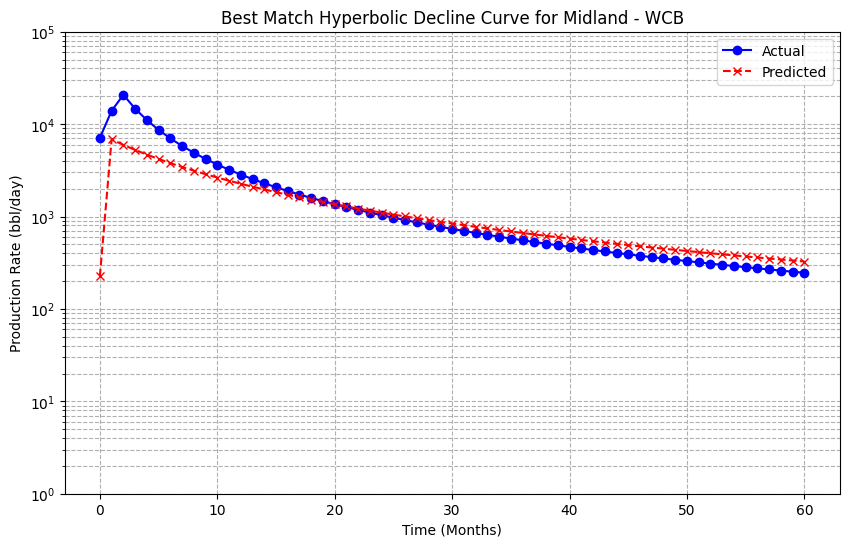

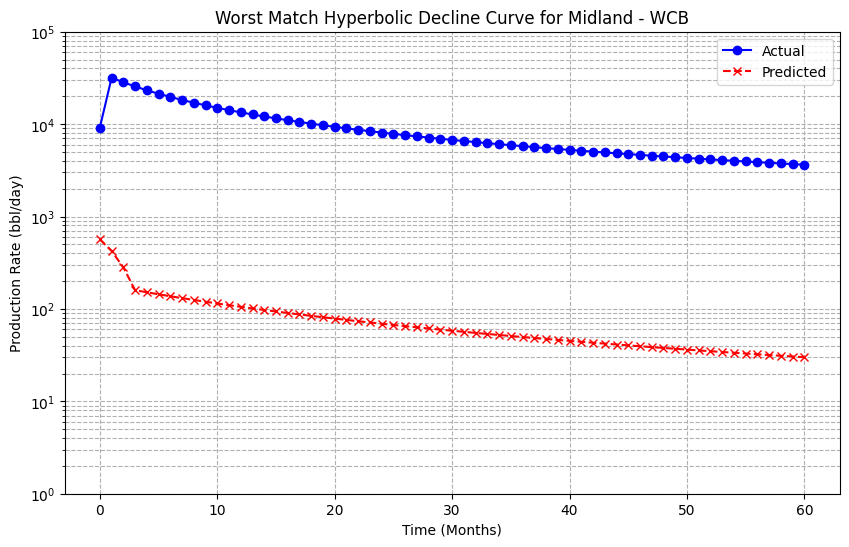

Performance for Basin: Midland, Formation: WCB, Config: xgboost - MSE: 305706504.5944, MAE: 5722.3153, sMAPE: 124.81%
Best Performing Model for Basin: Midland, Formation: LSS - Config: xgboost - MSE: 297266328.9092, MAE: 6104.5030, sMAPE: 119.72%
Best Performing Model for Basin: Midland, Formation: WCA - Config: random_forest - MSE: 118356922.7439, MAE: 3378.1165, sMAPE: 127.73%
Best Performing Model for Basin: Midland, Formation: JMS - Config: xgboost - MSE: 212158665.8459, MAE: 5010.3678, sMAPE: 119.83%
Best Performing Model for Basin: Midland, Formation: WCB - Config: decision_tree - MSE: 288301433.9832, MAE: 5864.4848, sMAPE: 122.54%


In [61]:
# Evaluate the models
evaluation_results = {}
best_performing_models = {}
time_array = np.linspace(0, 60, 61)  # Example time array for 60 months

for (basin, formation, config_str), model in models.items():
    # Filter the test data for the specific basin and formation
    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    
    # Extract numerical and categorical data from the filtered test set
    numerical_data = combo_test[numerical_columns].values
    categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
    
    # Prepare the target values (y_true)
    y_true = combo_test[y_headers].values  # Use entire y_headers as output

    # Predict outputs using the model
    y_pred = predict_with_model(model, numerical_data, categorical_data)

    # Denormalize predictions and actual values
    y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)
    y_true_denormalized = denormalize_data_output(y_true, output_scaler, log_transform_columns)
    
    # Ensure shapes match before calculating errors
    if y_true_denormalized.shape == y_pred_denormalized.shape:
        # Generate production rates
        predicted_productions, actual_productions = generate_production_rates(y_pred_denormalized, y_true_denormalized, y_headers, time_array)

        # Calculate errors
        errors = calculate_errors(predicted_productions, actual_productions)

        # If there are no valid errors, skip this model
        if not errors['MSE']:
            print(f"No valid predictions for Basin: {basin}, Formation: {formation}, Config: {config_str}. Skipping.")
            continue

        # Identify best and worst matches
        best_match_true, best_match_pred, worst_match_true, worst_match_pred, best_match_idx, worst_match_idx = identify_best_worst_matches(errors['sMAPE'], y_true_denormalized, y_pred_denormalized)

        # Plot the best match
        best_actual_production = actual_productions[best_match_idx]
        best_predicted_production = predicted_productions[best_match_idx]
        plot_decline_curves(time_array, best_actual_production, best_predicted_production, f'Best Match Hyperbolic Decline Curve for {basin} - {formation}')

        # Plot the worst match
        worst_actual_production = actual_productions[worst_match_idx]
        worst_predicted_production = predicted_productions[worst_match_idx]
        plot_decline_curves(time_array, worst_actual_production, worst_predicted_production, f'Worst Match Hyperbolic Decline Curve for {basin} - {formation}')

        # Calculate evaluation metrics
        mse = mean_squared_error(y_true_denormalized, y_pred_denormalized)
        mae = mean_absolute_error(y_true_denormalized, y_pred_denormalized)
        smape = np.mean(np.abs(y_pred_denormalized - y_true_denormalized) / ((np.abs(y_true_denormalized) + np.abs(y_pred_denormalized)) / 2)) * 100
        
        evaluation_results[(basin, formation, config_str)] = {'MSE': mse, 'MAE': mae, 'sMAPE': smape}
        print(f"Performance for Basin: {basin}, Formation: {formation}, Config: {config_str} - MSE: {mse:.4f}, MAE: {mae:.4f}, sMAPE: {smape:.2f}%")
        
        # Update best performing model
        if (basin, formation) not in best_performing_models or mse < best_performing_models[(basin, formation)]['MSE']:
            best_performing_models[(basin, formation)] = {'MSE': mse, 'MAE': mae, 'sMAPE': smape, 'config_str': config_str, 'model': model}
    else:
        print(f"Shape mismatch between y_true {y_true_denormalized.shape} and y_pred {y_pred_denormalized.shape}, check data preparation steps.")
    
# Print the best performing model for each basin and formation
for (basin, formation), best_model_info in best_performing_models.items():
    print(f"Best Performing Model for Basin: {basin}, Formation: {formation} - Config: {best_model_info['config_str']} - MSE: {best_model_info['MSE']:.4f}, MAE: {best_model_info['MAE']:.4f}, sMAPE: {best_model_info['sMAPE']:.2f}%")

In [62]:
# Directory to save individual plots
output_dir = 'C:/Users/Prakhar.Sarkar/OneDrive - SRP Management Services/Documents/_For_Prakhar/covarianceplots/plots'
os.makedirs(output_dir, exist_ok=True)
#plots_by_combination = {}
#Ip and decline 
# 

In [63]:
plots_by_combination = {}

for (basin, formation, config_str), model in models.items():
    # Check if config_str indicates a neural network configuration
    if 'embedding_output_dim' in config_str or 'dense_layer_sizes' in config_str:
        model_type = 'Neural Network'
    else:
        model_type = config_str.split(' ')[0]  # Use the first part of the config_str as the model type

    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    numerical_data = combo_test[numerical_columns].values
    categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
    y_true = combo_test[y_headers].values

    y_pred = predict_with_model(model, numerical_data, categorical_data)
    y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)
    y_true_denormalized = denormalize_data_output(y_true, output_scaler, log_transform_columns)

    years = 5
    time_array = np.linspace(1, 12 * years, 12 * years)  # 5 Years

    # Generate production rates for each sample
    predicted_productions_list = []
    for i in range(y_pred_denormalized.shape[0]):
        qi_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_InitialProd')]
        di_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_DiCoefficient')]
        b_pred  = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_BCoefficient')]
        IBU_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_BuildupRate')]
        MBU_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_MonthsInProd')]
        Dlim_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_LimDeclineRate')]
        predicted_production = modified_hyperbolic(time_array, qi_pred, di_pred, b_pred, Dlim_pred, IBU_pred, MBU_pred)
        predicted_productions_list.append(predicted_production)

    predicted_productions_flat = np.array(predicted_productions_list).flatten()

    # Check if categorical columns are empty
    if categorical_columns:
        categorical_dummies = pd.get_dummies(combo_test[categorical_columns], drop_first=True)
        all_features = pd.concat([combo_test[numerical_columns], categorical_dummies], axis=1)
    else:
        all_features = combo_test[numerical_columns]

    # Repeat features to match the length of flattened predicted productions
    repeated_features = np.repeat(all_features.values, len(time_array), axis=0)

    # Ensure the repeated_features array matches the size of the predicted production rates
    if len(repeated_features) != len(predicted_productions_flat):
        raise ValueError(f"Feature DataFrame and predicted productions have different lengths: {len(repeated_features)} vs {len(predicted_productions_flat)}")

    # Calculate covariance
    cov_matrix = np.cov(repeated_features.T, predicted_productions_flat)
    feature_names = all_features.columns
    sensitivity = cov_matrix[:-1, -1]

    # Create a separate figure for each combination
    plt.figure(figsize=(14, 20))
    sns.barplot(x=sensitivity, y=feature_names)
    plt.title(f'{basin}-{formation} ({model_type})', fontsize=16, fontweight='bold')
    plt.xlabel('Covariance', fontsize=12, fontname='Arial')
    plt.ylabel('Input Features', fontsize=14, fontweight='bold', fontname='Arial')
    plt.xticks(fontsize=10, fontname='Arial')
    plt.yticks(fontsize=10, fontname='Arial')
    plt.tight_layout()
    
    # Save the plot
    plot_filename = os.path.join(output_dir, f'{basin}_{formation}_{model_type}.jpeg')
    plt.savefig(plot_filename, format='jpeg',dpi=(500))
    plt.close()
    
    # Store plot filename for grid organization
    if (basin, formation) not in plots_by_combination:
        plots_by_combination[(basin, formation)] = []
    plots_by_combination[(basin, formation)].append(plot_filename)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:10: RuntimeWarning: invalid value encountered in scalar divide
  di = np.clip(((1 - 0.01 * di) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Dlim = np.clip(((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b), epsilon, None)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  qlim = qi * (Dlim / di) ** (1.0 / b)
C:\Users\Prakhar.Sarkar\AppData\Local\Temp\ipykernel_23108\3552581958.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  q_model_hyp = qi * (1.0 + b * di * (t_hyp - MBU)) ** (-1.0 / b)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (35,) + inhomogeneous part.

In [ ]:
# Directory to save individual plots
output_dir = 'C:/Users/Prakhar.Sarkar/OneDrive - SRP Management Services/Documents/_For_Prakhar/EURcovarianceplots'
os.makedirs(output_dir, exist_ok=True)

In [ ]:
def cumulative_production_and_EUR(qi, di, b, Dlim, IBU, MBU, years=30, buildup_method='Linear'):
    months = np.linspace(0, years * 12, years * 12 + 1)
    production = modified_hyperbolic(months, qi, di, b, Dlim, IBU, MBU, buildup_method)
    cumulative_production = np.cumsum(production)
    EUR = cumulative_production[-1]
    return cumulative_production, EUR

def generate_EUR_predictions(models, test_df, numerical_columns, categorical_columns, output_scaler, log_transform_columns):
    EUR_predictions = {}
    for (basin, formation, config_str), model in models.items():
        combo_test = filter_by_basin_and_formation(test_df, basin, formation)
        numerical_data = combo_test[numerical_columns].values
        categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
        y_true = combo_test[y_headers].values

        y_pred = predict_with_model(model, numerical_data, categorical_data)
        y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)

        EUR_list = []
        for i in range(y_pred_denormalized.shape[0]):
            qi_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_InitialProd')]
            di_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_DiCoefficient')]
            b_pred  = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_BCoefficient')]
            IBU_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_BuildupRate')]
            MBU_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_MonthsInProd')]
            Dlim_pred = y_pred_denormalized.iloc[i, y_headers.index('Oil_Params_P50_LimDeclineRate')]
            _, EUR = cumulative_production_and_EUR(qi_pred, di_pred, b_pred, Dlim_pred, IBU_pred, MBU_pred)
            EUR_list.append(EUR)

        EUR_predictions[(basin, formation, config_str)] = np.array(EUR_list)
    return EUR_predictions

def denormalize_features(combo_test, numerical_columns, categorical_columns, input_scaler, encoders):
    denormalized_numerical = denormalize_data_input(combo_test[numerical_columns].values, input_scaler)
    decoded_categorical = decode_categorical(combo_test[categorical_columns].values, encoders, categorical_columns)
    
    combo_test_denorm = combo_test.copy()
    combo_test_denorm[numerical_columns] = denormalized_numerical
    for col in categorical_columns:
        combo_test_denorm[col] = decoded_categorical[col]
    return combo_test_denorm

def plot_feature_vs_EUR(combo_test, feature, EUR_values, output_dir, basin, formation, model_type):
    plt.figure(figsize=(10, 6))
    plt.scatter(combo_test[feature], EUR_values, alpha=0.5)
    
    # Adding a trend line
    model = LinearRegression()
    feature_values = combo_test[feature].values.reshape(-1, 1)
    model.fit(feature_values, EUR_values)
    trendline = model.predict(feature_values)
    plt.plot(combo_test[feature], trendline, color='red', linewidth=2, label='Trend line')

    # Calculating slope and R²
    slope = model.coef_[0]
    r2 = model.score(feature_values, EUR_values)

    # Adding text annotation for slope and R²
    plt.annotate(f'Slope: {slope:.2f}\nR²: {r2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10,
                 horizontalalignment='left', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

    plt.title(f'Feature: {feature} vs. EUR\n{basin}-{formation} ({model_type})', fontsize=16)
    plt.xlabel(f'{feature}', fontsize=12)
    plt.ylabel('EUR', fontsize=12)
    plt.grid(True)
    plt.legend()
    
    # Adding whitespace below the plot for footnotes
    plt.subplots_adjust(bottom=0.25)
    
    # Adding footnotes as text below the plot
    footnote = f'{feature}: {"Positive" if np.cov(combo_test[feature].values, EUR_values)[0, 1] > 0 else "Negative"} covariance with EUR.'
    plt.figtext(0.5, -0.01, footnote, wrap=True, horizontalalignment='center', fontsize=10)
    
    plot_filename = os.path.join(output_dir, f'{feature}_vs_EUR.jpeg')
    plt.savefig(plot_filename, format='jpeg', dpi=300, bbox_inches='tight')
    plt.close()
    
    return plot_filename

def calculate_covariance(combo_test, EUR_values, feature):
    feature_values = combo_test[feature].values
    if len(feature_values) > 1:
        covariance = np.cov(feature_values, EUR_values)[0, 1]
    else:
        covariance = np.nan
    return covariance

In [ ]:
plots_by_combination = {}

EUR_predictions = generate_EUR_predictions(models, test_df, numerical_columns, categorical_columns, output_scaler, log_transform_columns)

for (basin, formation, config_str), EUR_pred in EUR_predictions.items():
    if 'embedding_output_dim' in config_str or 'dense_layer_sizes' in config_str:
        model_type = 'Neural Network'
    else:
        model_type = config_str.split(' ')[0]

    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    combo_test_denorm = denormalize_features(combo_test, numerical_columns, categorical_columns, input_scaler, encoders)

    basin_formation_dir = os.path.join(output_dir, f'{basin}_{formation}')
    method_dir = os.path.join(basin_formation_dir, model_type)
    os.makedirs(method_dir, exist_ok=True)

    plot_filenames = []
    covariances = {}
    for feature in numerical_columns + categorical_columns:
        plot_filename = plot_feature_vs_EUR(combo_test_denorm, feature, EUR_pred, method_dir, basin, formation, model_type)
        plot_filenames.append(plot_filename)
        covariance = calculate_covariance(combo_test_denorm, EUR_pred, feature)
        covariances[feature] = covariance

    sorted_features = sorted(covariances.items(), key=lambda item: abs(item[1]), reverse=True)
    features, covariances = zip(*sorted_features)

    plt.figure(figsize=(14, 20))
    sns.barplot(x=covariances, y=features)
    plt.title(f'{basin}-{formation} ({model_type})', fontsize=16, fontweight='bold')
    plt.xlabel('Covariance with EUR', fontsize=12, fontname='Arial')
    plt.ylabel('Input Features', fontsize=14, fontweight='bold', fontname='Arial')
    plt.xticks(fontsize=10, fontname='Arial')
    plt.yticks(fontsize=10, fontname='Arial')
    plt.tight_layout()

    # Adding critical comments as footnotes
    footnotes = "\n".join([f"{feature}: {'Positive' if cov > 0 else 'Negative'} covariance with EUR."
                           for feature, cov in sorted_features])
    plt.figtext(0.5, -0.4, footnotes, wrap=True, horizontalalignment='center', fontsize=12)

    cov_plot_filename = os.path.join(method_dir, 'covariance_plot.jpeg')
    plt.savefig(cov_plot_filename, format='jpeg', dpi=500, bbox_inches='tight')
    plt.close()

    if (basin, formation) not in plots_by_combination:
        plots_by_combination[(basin, formation)] = []
    plots_by_combination[(basin, formation)].append(cov_plot_filename)

print("Plots generated and saved successfully.")

In [ ]:
# Load the saved plots and stitch them together into a grid for each combination
for (basin, formation), plot_filenames in plots_by_combination.items():
    images = [Image.open(filename) for filename in plot_filenames]

    # Determine the number of rows and columns for the grid
    num_plots = len(images)
    num_cols = 4  # Set the number of columns for the grid
    num_rows = (num_plots + num_cols - 1) // num_cols

    # Get the dimensions of the images
    image_width, image_height = images[0].size

    # Create a new blank image for the grid
    grid_image = Image.new('RGB', (num_cols * image_width, num_rows * image_height))

    # Paste each plot image into the grid
    for index, image in enumerate(images):
        row = index // num_cols
        col = index % num_cols
        grid_image.paste(image, (col * image_width, row * image_height))

    # Save the final grid image for the combination
    grid_image.save(f'C:/Users/Prakhar.Sarkar/OneDrive - SRP Management Services/Documents/_For_Prakhar/covarianceplots/{basin}_{formation}_grid_image.jpeg', format='jpeg')

In [ ]:
# plots_by_combination = {}

# for (basin, formation, config_str), model in models.items():
#     # Check if config_str indicates a neural network configuration
#     if 'embedding_output_dim' in config_str or 'dense_layer_sizes' in config_str:
#         model_type = 'Neural Network'
#     else:
#         model_type = config_str.split(' ')[0]  # Use the first part of the config_str as the model type

#     combo_test = filter_by_basin_and_formation(test_df, basin, formation)
#     numerical_data = combo_test[numerical_columns].values
#     categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]

#     # Debugging: Print shapes
#     print(f"Processing {basin}-{formation} ({model_type})")
#     print(f"Numerical data shape: {numerical_data.shape}")

#     if model_type == 'Neural Network':
#         # Use KernelExplainer for neural networks
#         explainer = shap.KernelExplainer(model.predict, numerical_data)
#         shap_values = explainer.shap_values(numerical_data, nsamples=100)
#     # else:
#     #     # Extract the actual model from the pipeline if necessary
#     #     if isinstance(model, Pipeline):
#     #         model = model.named_steps['model']
        
#     #     # Example for tree-based models (RandomForest, XGBoost)
#     #     # Use TreeExplainer for tree-based models
#     #     explainer = shap.TreeExplainer(model)
#     #     shap_values = explainer.shap_values(combo_test[numerical_columns])

#     # Debugging: Print shapes of SHAP values
#     print(f"SHAP values shape: {np.array(shap_values).shape}")

#     # Ensure SHAP values have the correct shape
#     if isinstance(shap_values, list):
#         shap_values = shap_values[0]  # Select the first output if it's a list of arrays

#     # If SHAP values have three dimensions, select the appropriate slice
#     if shap_values.ndim == 3:
#         shap_values = shap_values[:, :, 0]  # Assuming we are interested in the first output

#     # Summary plot of SHAP values
#     shap.summary_plot(shap_values, combo_test[numerical_columns], plot_type="bar")
#     plt.title(f'{basin}-{formation} ({model_type}) SHAP Summary')
#     plt.tight_layout()
#     plt.show()

In [ ]:
def ensure_directory_exists(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

In [ ]:
def find_best_performing_index(models, test_df, numerical_columns, categorical_columns, y_headers, output_scaler, log_transform_columns):
    best_performing_indices = {}
    for (basin, formation, config_str), model in models.items():
        combo_test = filter_by_basin_and_formation(test_df, basin, formation)
        numerical_data = combo_test[numerical_columns].values
        categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
        y_true = combo_test[y_headers].values
        
        y_pred = predict_with_model(model, numerical_data, categorical_data)
        y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)
        y_true_denormalized = denormalize_data_output(y_true, output_scaler, log_transform_columns)

        mse = mean_squared_error(y_true_denormalized, y_pred_denormalized, multioutput='raw_values')
        
        if mse.size > 0:
            best_match_idx = mse.mean(axis=0).argmin()
            if (basin, formation) not in best_performing_indices or mse.mean() < best_performing_indices[(basin, formation)]['mse']:
                best_performing_indices[(basin, formation)] = {
                    'index': best_match_idx,
                    'mse': mse.mean()
                }
    return best_performing_indices

def identify_best_performing_rows(models, test_df, numerical_columns, categorical_columns, y_headers, output_scaler, log_transform_columns, best_performing_indices):
    best_performing_rows = {}
    for (basin, formation, config_str), model in models.items():
        combo_test = filter_by_basin_and_formation(test_df, basin, formation)
        best_match_idx = best_performing_indices[(basin, formation)]['index']
        best_match_row = combo_test.iloc[best_match_idx]
        
        best_performing_rows[(basin, formation, config_str)] = {
            'model': model,
            'best_match_row': best_match_row
        }
    return best_performing_rows

def generate_sensitivity_data(best_performing_row, model, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array):
    variations = {
        'HORIZONTIAL_WELL_LENGTH': np.arange(8000, 11500, 500),
        'ProppantPerFoot': np.arange(1000, 2200, 200),
        'FluidPerFoot_bblft': np.arange(40, 70, 10)
    }
    
    results = {key: [] for key in variations.keys()}
    
    for param, values in variations.items():
        for value in values:
            modified_row = best_performing_row.copy()
            modified_row[param] = value
            
            scaled_numerical = input_scaler.transform(pd.DataFrame([modified_row[numerical_columns]], columns=numerical_columns))
            categorical_data = [modified_row[col].astype(int).reshape(-1, 1) for col in categorical_columns]
            y_pred = predict_with_model(model, scaled_numerical, categorical_data)
            y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)
            
            # Convert to NumPy array for indexing
            y_pred_denormalized = np.array(y_pred_denormalized)

            production_rates = modified_hyperbolic(time_array, 
                                                   y_pred_denormalized[0, y_headers.index('Oil_Params_P50_InitialProd')],
                                                   y_pred_denormalized[0, y_headers.index('Oil_Params_P50_DiCoefficient')],
                                                   y_pred_denormalized[0, y_headers.index('Oil_Params_P50_BCoefficient')],
                                                   y_pred_denormalized[0, y_headers.index('Oil_Params_P50_LimDeclineRate')],
                                                   y_pred_denormalized[0, y_headers.index('Oil_Params_P50_BuildupRate')],
                                                   y_pred_denormalized[0, y_headers.index('Oil_Params_P50_MonthsInProd')])
            results[param].append((value, production_rates))
    
    return results

def plot_sensitivity_analysis(results, time_array, param, ax, method):
    for value, production in results[param]:
        ax.plot(time_array, production, label=f'{param}={value}')
    ax.set_yscale('log')
    ax.set_xlabel('Time (Months)', fontsize=12, fontname='Arial')
    ax.set_ylabel('Production Rate (bbl/day)', fontsize=12, fontname='Arial')
    wrapped_title = "\n".join(wrap(f'Sensitivity Analysis for {param} ({method})', 30))
    ax.set_title(wrapped_title, fontsize=14, fontweight='bold', fontname='Arial')
    ax.legend()
    ax.grid(True, which='both', linestyle='--')

def save_combined_grid_plot(best_performing_rows, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array, output_dir):
    plots_by_combination = {}
    
    for (basin, formation, config_str), info in best_performing_rows.items():
        model = info['model']
        best_match_row = info['best_match_row']
        results = generate_sensitivity_data(best_match_row, model, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array)
        
        method = 'Neural Network' if 'embedding_output_dim' in config_str else config_str.split(' ')[0]
        
        if (basin, formation) not in plots_by_combination:
            plots_by_combination[(basin, formation)] = {'methods': [], 'results': []}
        
        plots_by_combination[(basin, formation)]['methods'].append(method)
        plots_by_combination[(basin, formation)]['results'].append(results)

    for (basin, formation), data in plots_by_combination.items():
        methods = data['methods']
        results_list = data['results']
        
        fig, axs = plt.subplots(len(methods), 3, figsize=(20, 6 * len(methods)))
        fig.subplots_adjust(hspace=0.6, wspace=0.4)
        
        for i, (method, results) in enumerate(zip(methods, results_list)):
            for j, param in enumerate(results.keys()):
                plot_sensitivity_analysis(results, time_array, param, axs[i, j], method)
        
        overall_title = f'Sensitivity Analysis for {basin} - {formation}'
        fig.suptitle(overall_title, fontsize=16, fontweight='bold', fontname='Arial')

        basin_formation_dir = os.path.join(output_dir, f"{basin}_{formation}")
        ensure_directory_exists(basin_formation_dir)
        
        plot_filename = os.path.join(basin_formation_dir, f'sensitivity_analysis_combined.png')
        plt.savefig(plot_filename, format='png', dpi=300)
        plt.close()
        
def save_grid_plot(best_performing_rows, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array, output_dir):
    for (basin, formation, config_str), info in best_performing_rows.items():
        model = info['model']
        best_match_row = info['best_match_row']
        results = generate_sensitivity_data(best_match_row, model, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array)
        
        method = 'Neural Network' if 'embedding_output_dim' in config_str else config_str.split(' ')[0]
        
        fig, axs = plt.subplots(1, 3, figsize=(20, 6))
        fig.subplots_adjust(hspace=0.6, wspace=0.4)
        
        for j, param in enumerate(results.keys()):
            plot_sensitivity_analysis(results, time_array, param, axs[j], method)
        
        overall_title = f'Sensitivity Analysis for {basin} - {formation} ({method})'
        fig.suptitle(overall_title, fontsize=16, fontweight='bold', fontname='Arial')

        # Create the directory for saving plots if it does not exist
        basin_formation_dir = os.path.join(output_dir, f"{basin}_{formation}")
        ensure_directory_exists(basin_formation_dir)
        
        # Save the plot
        plot_filename = os.path.join(basin_formation_dir, f'{method}_sensitivity_analysis.png')
        plt.savefig(plot_filename, format='png', dpi=300)
        plt.close()

# Example usage:
output_dir = 'sensitivity_analysis_plots'
time_array = np.linspace(0, 60, 61)  # Example time array for 60 months
best_performing_indices = find_best_performing_index(models, test_df, numerical_columns, categorical_columns, y_headers, output_scaler, log_transform_columns)
best_performing_rows = identify_best_performing_rows(models, test_df, numerical_columns, categorical_columns, y_headers, output_scaler, log_transform_columns, best_performing_indices)
save_combined_grid_plot(best_performing_rows, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array, output_dir)
save_grid_plot(best_performing_rows, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array, output_dir)

In [ ]:
# def identify_best_performing_rows(models, test_df, numerical_columns, categorical_columns, y_headers, output_scaler, log_transform_columns):
#     best_performing_rows = {}
#     for (basin, formation, config_str), model in models.items():
#         combo_test = filter_by_basin_and_formation(test_df, basin, formation)
#         numerical_data = combo_test[numerical_columns].values
#         categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
#         y_true = combo_test[y_headers].values
        
#         y_pred = predict_with_model(model, numerical_data, categorical_data)
#         y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)
#         y_true_denormalized = denormalize_data_output(y_true, output_scaler, log_transform_columns)

#         mse = mean_squared_error(y_true_denormalized, y_pred_denormalized, multioutput='raw_values')
        
#         if mse.size > 0:
#             best_match_idx = mse.mean(axis=0).argmin()
#             if best_match_idx < len(combo_test):
#                 best_match_row = combo_test.iloc[best_match_idx]
#             else:
#                 continue
#         else:
#             continue

#         best_performing_rows[(basin, formation, config_str)] = {
#             'model': model,
#             'best_match_row': best_match_row
#         }
#     return best_performing_rows


In [ ]:
# def generate_sensitivity_data(best_performing_row, model, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array):
#     variations = {
#         'HORIZONTIAL_WELL_LENGTH': np.arange(8000, 11500, 500),
#         'ProppantPerFoot': np.arange(1000, 2200, 200),
#         'FluidPerFoot_bblft': np.arange(40, 70, 10)
#     }
    
#     results = {key: [] for key in variations.keys()}
    
#     for param, values in variations.items():
#         for value in values:
#             modified_row = best_performing_row.copy()
#             modified_row[param] = value
            
#             scaled_numerical = input_scaler.transform(pd.DataFrame([modified_row[numerical_columns]], columns=numerical_columns))
#             categorical_data = [modified_row[col].astype(int).reshape(-1, 1) for col in categorical_columns]
#             y_pred = predict_with_model(model, scaled_numerical, categorical_data)
#             y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)
            
#             # Convert to NumPy array for indexing
#             y_pred_denormalized = np.array(y_pred_denormalized)

#             production_rates = modified_hyperbolic(time_array, 
#                                                    y_pred_denormalized[0, y_headers.index('Oil_Params_P50_InitialProd')],
#                                                    y_pred_denormalized[0, y_headers.index('Oil_Params_P50_DiCoefficient')],
#                                                    y_pred_denormalized[0, y_headers.index('Oil_Params_P50_BCoefficient')],
#                                                    y_pred_denormalized[0, y_headers.index('Oil_Params_P50_LimDeclineRate')],
#                                                    y_pred_denormalized[0, y_headers.index('Oil_Params_P50_BuildupRate')],
#                                                    y_pred_denormalized[0, y_headers.index('Oil_Params_P50_MonthsInProd')])
#             results[param].append((value, production_rates))
    
#     return results


In [ ]:
# def plot_sensitivity_analysis(results, time_array, param, ax, method):
#     for value, production in results[param]:
#         ax.plot(time_array, production, label=f'{param}={value}')
#     ax.set_yscale('log')
#     ax.set_xlabel('Time (Months)', fontsize=12, fontname='Arial')
#     ax.set_ylabel('Production Rate (bbl/day)', fontsize=12, fontname='Arial')
#     wrapped_title = "\n".join(wrap(f'Sensitivity Analysis for {param} ({method})', 30))
#     ax.set_title(wrapped_title, fontsize=14, fontweight='bold', fontname='Arial')
#     ax.legend()
#     ax.grid(True, which='both', linestyle='--')

# def save_combined_grid_plot(best_performing_rows, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array, output_dir):
#     plots_by_combination = {}
    
#     for (basin, formation, config_str), info in best_performing_rows.items():
#         model = info['model']
#         best_match_row = info['best_match_row']
#         results = generate_sensitivity_data(best_match_row, model, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array)
        
#         method = 'Neural Network' if 'embedding_output_dim' in config_str else config_str.split(' ')[0]
        
#         if (basin, formation) not in plots_by_combination:
#             plots_by_combination[(basin, formation)] = {'methods': [], 'results': []}
        
#         plots_by_combination[(basin, formation)]['methods'].append(method)
#         plots_by_combination[(basin, formation)]['results'].append(results)

#     for (basin, formation), data in plots_by_combination.items():
#         methods = data['methods']
#         results_list = data['results']
        
#         fig, axs = plt.subplots(len(methods), 3, figsize=(20, 6 * len(methods)))
#         fig.subplots_adjust(hspace=0.6, wspace=0.4)
        
#         for i, (method, results) in enumerate(zip(methods, results_list)):
#             for j, param in enumerate(results.keys()):
#                 plot_sensitivity_analysis(results, time_array, param, axs[i, j], method)
        
#         overall_title = f'Sensitivity Analysis for {basin} - {formation}'
#         fig.suptitle(overall_title, fontsize=16, fontweight='bold', fontname='Arial')

#         basin_formation_dir = os.path.join(output_dir, f"{basin}_{formation}")
#         ensure_directory_exists(basin_formation_dir)
        
#         plot_filename = os.path.join(basin_formation_dir, f'sensitivity_analysis_combined.png')
#         plt.savefig(plot_filename, format='png', dpi=300)
#         plt.close()
        
# def save_grid_plot(best_performing_rows, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array, output_dir):
#     for (basin, formation, config_str), info in best_performing_rows.items():
#         model = info['model']
#         best_match_row = info['best_match_row']
#         results = generate_sensitivity_data(best_match_row, model, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time)
        
#         method = 'Neural Network' if 'embedding_output_dim' in config_str else config_str.split(' ')[0]
        
#         fig, axs = plt.subplots(1, 3, figsize=(20, 6))
#         fig.subplots_adjust(hspace=0.6, wspace=0.4)
        
#         for j, param in enumerate(results.keys()):
#             plot_sensitivity_analysis(results, time_array, param, axs[j], method)
        
#         overall_title = f'Sensitivity Analysis for {basin} - {formation} ({method})'
#         fig.suptitle(overall_title, fontsize=16, fontweight='bold', fontname='Arial')

#         # Create the directory for saving plots if it does not exist
#         basin_formation_dir = os.path.join(output_dir, f"{basin}_{formation}")
#         ensure_directory_exists(basin_formation_dir)
        
#         # Save the plot
#         plot_filename = os.path.join(basin_formation_dir, f'{method}_sensitivity_analysis.png')
#         plt.savefig(plot_filename, format='png', dpi=300)
#         plt.close()



In [ ]:
# # Example usage:
# # Example usage:
# output_dir = 'sensitivity_analysis_plots'
# ttime_array = np.linspace(1, 12 * years, 12 * years)  # Example time array for 60 months
# best_performing_rows = identify_best_performing_rows(models, test_df, numerical_columns, categorical_columns, y_headers, output_scaler, log_transform_columns)
# save_combined_grid_plot(best_performing_rows, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array, output_dir)
# save_grid_plot(best_performing_rows, numerical_columns, categorical_columns, input_scaler, output_scaler, log_transform_columns, y_headers, time_array, output_dir)

In [ ]:
import pickle

# Defining a dictionary to store all outputs
outputs = {
    'train_df': train_df,
    'val_df': val_df,
    'test_df': test_df,
    'models': models,
    #'shap_values_dict': shap_values_dict,
    'evaluation_results': evaluation_results,
    'best_performing_models': best_performing_models,
    'task_times': task_times,
    'y_headers': y_headers,
    'numerical_columns': numerical_columns,
    'categorical_columns': categorical_columns
}

# Saving the dictionary to a pickle file
output_file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\outputs.pkl'
with open(output_file_path, 'wb') as file:
    pickle.dump(outputs, file)

output_file_path

In [ ]:
# Read the first Excel sheet (cumulative data)
file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\TCTest.xlsx'
Test_df = pd.read_excel(file_path)

In [ ]:
Test_df

In [ ]:
# Columns to be parsed
param_columns = [
    'Oil_Params_P50', 'Gas_Params_P50', 'Water_Params_P50'
]
# Apply robust parsing to each column
for col in param_columns:
    Test_df[col] = Test_df[col].apply(robust_parse)
# Split each parameter into its own column
new_columns = []
for col in param_columns:
    expanded_cols = [f'{col}_Method', f'{col}_BuildupRate', f'{col}_MonthsInProd', 
                     f'{col}_InitialProd', f'{col}_DiCoefficient', f'{col}_BCoefficient', 
                     f'{col}_LimDeclineRate']
    temp_df = pd.DataFrame(Test_df[col].tolist(), columns=expanded_cols)
    # Convert numeric columns to float
    for num_col in expanded_cols:
        if num_col.endswith('_Method'):
            temp_df[num_col] = temp_df[num_col].astype(str)  # Ensuring 'Method' is of string type
        else:
            temp_df[num_col] = pd.to_numeric(temp_df[num_col], errors='coerce')  # Convert to numeric and handle errors
    Test_df = pd.concat([Test_df, temp_df], axis=1)

# Drop the original parameter columns
Test_df.drop(columns=param_columns, inplace=True)

In [ ]:
def preprocess_test_data(test_df, numerical_columns, categorical_columns, input_scaler):
    numerical_data = test_df[numerical_columns].values
    scaled_numerical = input_scaler.transform(numerical_data)
    
    categorical_data = [test_df[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
    
    return scaled_numerical, categorical_data

# Assuming test_df is already defined
scaled_numerical, categorical_data = preprocess_test_data(Test_df, numerical_columns, categorical_columns, input_scaler)


In [ ]:
def generate_predictions(models, scaled_numerical, categorical_data, output_scaler, log_transform_columns):
    predictions = {}
    
    for (basin, formation, config_str), model in models.items():
        y_pred = predict_with_model(model, scaled_numerical, categorical_data)
        y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)
        predictions[(basin, formation, config_str)] = y_pred_denormalized
        
    return predictions

predictions = generate_predictions(models, scaled_numerical, categorical_data, output_scaler, log_transform_columns)


In [ ]:
def generate_production_rates(y_pred_denormalized, y_true_denormalized, headers, time):
    predicted_productions = []
    actual_productions = []

    for idx in range(len(y_pred_denormalized)):
        qi_pred = y_pred_denormalized[idx, headers.index('Oil_Params_P50_InitialProd')]
        di_pred = y_pred_denormalized[idx, headers.index('Oil_Params_P50_DiCoefficient')]
        b_pred  = y_pred_denormalized[idx, headers.index('Oil_Params_P50_BCoefficient')]
        IBU_pred = y_pred_denormalized[idx, headers.index('Oil_Params_P50_BuildupRate')]
        MBU_pred = y_pred_denormalized[idx, headers.index('Oil_Params_P50_MonthsInProd')]
        Dlim_pred = y_pred_denormalized[idx, headers.index('Oil_Params_P50_LimDeclineRate')]
        
        qi_true = y_true_denormalized[idx, headers.index('Oil_Params_P50_InitialProd')]
        di_true = y_true_denormalized[idx, headers.index('Oil_Params_P50_DiCoefficient')]
        b_true = y_true_denormalized[idx, headers.index('Oil_Params_P50_BCoefficient')]
        IBU_true = y_true_denormalized[idx, headers.index('Oil_Params_P50_BuildupRate')]
        MBU_true = y_true_denormalized[idx, headers.index('Oil_Params_P50_MonthsInProd')]
        Dlim_true = y_true_denormalized[idx, headers.index('Oil_Params_P50_LimDeclineRate')]
        
        predicted_production = modified_hyperbolic(time, qi_pred, di_pred, b_pred, Dlim_pred, IBU_pred, MBU_pred)
        actual_production = modified_hyperbolic(time, qi_true, di_true, b_true, Dlim_true, IBU_true, MBU_true)
        
        predicted_productions.append(predicted_production)
        actual_productions.append(actual_production)

    return predicted_productions, actual_productions


In [ ]:
def plot_comparison(test_df, predictions, y_headers, time):
    for (basin, formation, config_str), y_pred in predictions.items():
        y_true = test_df[y_headers].values
        y_true_denormalized = denormalize_data_output(y_true, output_scaler, log_transform_columns).values

        # Generate production rates
        predicted_productions, actual_productions = generate_production_rates(y_pred.values, y_true_denormalized, y_headers, time)

        for idx in range(len(predicted_productions)):
            plot_decline_curves(time, actual_productions[idx], predicted_productions[idx], f'Predicted vs Actual Decline Curve for {basin} - {formation} - {config_str} - Point {idx+1}')

# Example usage
years = 5
time = np.linspace(1, 12 * years, 12 * years)  # 5 Years
plot_comparison(Test_df, predictions, y_headers, time)
